# MCTNet — Entraînement & Évaluation Comparée
## Arkansas · California × {soil | clim | topo | all}
**Wang et al., 2024**

Ce notebook entraîne **MCTNetWithCovars** sur les deux régions (Arkansas et California)
pour les 4 groupes de covariables, puis affiche toutes les comparaisons côte à côte.

## CELLULE 0 — Montage Drive & vérification GPU

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
print('GPU disponible :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU :', torch.cuda.get_device_name(0))

import os, sys

# ── Modifiez ces chemins ──────────────────────────────────────────────────────
NPY_DIR  = '/content/drive/MyDrive/data_part2/TES_preprocessesd'          # dossier des .npy
CODE_DIR = '/content/drive/MyDrive/src'    # dossier contenant src/mctnet.py
# ─────────────────────────────────────────────────────────────────────────────

sys.path.append(CODE_DIR)

print('\nVérification des fichiers .npy :')
for region in ['Arkansas', 'California']:
    for split in ['train', 'val', 'test']:
        for suffix in ['input1', 'input2', 'labels']:
            f = f'{NPY_DIR}/{region}_{split}_{suffix}.npy'
            status = '✔' if os.path.exists(f) else '✘ MANQUANT'
            print(f'  {status}  {region}_{split}_{suffix}.npy')

Mounted at /content/drive
GPU disponible : True
GPU : Tesla T4

Vérification des fichiers .npy :
  ✔  Arkansas_train_input1.npy
  ✔  Arkansas_train_input2.npy
  ✔  Arkansas_train_labels.npy
  ✔  Arkansas_val_input1.npy
  ✔  Arkansas_val_input2.npy
  ✔  Arkansas_val_labels.npy
  ✔  Arkansas_test_input1.npy
  ✔  Arkansas_test_input2.npy
  ✔  Arkansas_test_labels.npy
  ✔  California_train_input1.npy
  ✔  California_train_input2.npy
  ✔  California_train_labels.npy
  ✔  California_val_input1.npy
  ✔  California_val_input2.npy
  ✔  California_val_labels.npy
  ✔  California_test_input1.npy
  ✔  California_test_input2.npy
  ✔  California_test_labels.npy


## Imports

In [2]:
import os
import time
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, cohen_kappa_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print('PyTorch :', torch.__version__)
print('Device  :', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch : 2.10.0+cu128
Device  : cuda


## Architecture MCTNet

## — Positional Encoding & Attention (ECA, ALPE, Transformer)

In [3]:
# ═══════════════════════════════════════════════════════════════
#  Sinusoidal Positional Encoding
# ═══════════════════════════════════════════════════════════════

def sinusoidal_pe(seq_len: int, d_model: int, device=None) -> torch.Tensor:
    pe = torch.zeros(seq_len, d_model, device=device)
    position = torch.arange(0, seq_len, dtype=torch.float, device=device).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float, device=device)
        * (-math.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term[: d_model // 2])
    return pe  # (T, C)


# ═══════════════════════════════════════════════════════════════
#  ECA — Efficient Channel Attention
# ═══════════════════════════════════════════════════════════════

class ECA(nn.Module):
    def __init__(self, channels: int, gamma: int = 2, b: int = 1):
        super().__init__()
        t = int(abs(math.log2(channels) / gamma + b / gamma))
        k = t if t % 2 else t + 1
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=k, padding=k // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y = self.avg_pool(x).squeeze(-1).unsqueeze(1)
        y = self.sigmoid(self.conv(y)).squeeze(1).unsqueeze(-1)
        return x * y.expand_as(x)


# ═══════════════════════════════════════════════════════════════
#  ALPE — Adaptive Local Positional Encoding
# ═══════════════════════════════════════════════════════════════

class ALPE(nn.Module):
    def __init__(self, channels: int, seq_len: int, kernel_size: int = 3):
        super().__init__()
        self.channels = channels
        self.seq_len  = seq_len
        pe = sinusoidal_pe(seq_len, channels)
        self.register_buffer('pe', pe)   # (T, C)
        padding   = kernel_size // 2
        self.conv = nn.Conv1d(channels, channels, kernel_size=kernel_size,
                              padding=padding, bias=False)
        self.bn   = nn.BatchNorm1d(channels)
        self.eca  = ECA(channels)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        mask_bc  = mask.unsqueeze(1).float()           # (B, 1, T)
        pe_bct   = self.pe.T.unsqueeze(0)              # (1, C, T)
        masked_pe = pe_bct * mask_bc                   # (B, C, T)
        out = F.relu(self.bn(self.conv(masked_pe)))    # (B, C, T)
        out = self.eca(out)
        return x + out


# ═══════════════════════════════════════════════════════════════
#  TransformerSubModule
# ═══════════════════════════════════════════════════════════════

class TransformerSubModule(nn.Module):
    def __init__(self, channels: int, seq_len: int, n_head: int = 5,
                 use_alpe: bool = False, kernel_size: int = 3, dropout: float = 0.1):
        super().__init__()
        self.use_alpe = use_alpe
        if use_alpe:
            self.alpe = ALPE(channels, seq_len, kernel_size)
        self.attn  = nn.MultiheadAttention(embed_dim=channels, num_heads=n_head,
                                            dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(channels)
        ffn_dim    = 8 * channels
        self.ffn   = nn.Sequential(
            nn.Linear(channels, ffn_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(ffn_dim, channels), nn.Dropout(dropout),
        )
        self.norm2 = nn.LayerNorm(channels)

    def forward(self, x: torch.Tensor, mask: torch.Tensor | None = None) -> torch.Tensor:
        if self.use_alpe:
            if mask is None:
                raise ValueError('Masque requis quand use_alpe=True')
            x = self.alpe(x, mask)
        x_t = x.permute(0, 2, 1)                              # (B, T, C)
        attn_out, _ = self.attn(x_t, x_t, x_t)
        x_t = self.norm2(self.ffn(self.norm1(x_t + attn_out)) + self.norm1(x_t + attn_out))
        return x_t.permute(0, 2, 1)

## — CNNSubModule

In [4]:
class CNNSubModule(nn.Module):
    def __init__(self, in_channels: int, kernel_size: int = 3):
        super().__init__()
        p = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels, in_channels, kernel_size=kernel_size, padding=p, bias=False)
        self.bn1   = nn.BatchNorm1d(in_channels)
        self.conv2 = nn.Conv1d(in_channels, in_channels, kernel_size=kernel_size, padding=p, bias=False)
        self.bn2   = nn.BatchNorm1d(in_channels)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        out = self.bn1(self.conv1(x))
        out = self.bn2(self.conv2(out))
        return self.relu(out + residual)

## — CTFusion

In [5]:
class CTFusion(nn.Module):
    """
    CNN-Transformer Fusion block (Wang et al., 2024 — Figure 3).
    Stage 1 : (B, 10, 36) → (B, 20, 18)   [use_alpe=True]
    Stage 2 : (B, 20, 18) → (B, 40,  9)
    Stage 3 : (B, 40,  9) → (B, 80,  4)
    """
    def __init__(self, in_channels: int, seq_len: int, n_head: int = 5,
                 kernel_size: int = 3, use_alpe: bool = False, dropout: float = 0.1):
        super().__init__()
        self.cnn         = CNNSubModule(in_channels, kernel_size)
        self.transformer = TransformerSubModule(in_channels, seq_len, n_head,
                                                use_alpe, kernel_size, dropout)
        self.pool        = nn.MaxPool1d(kernel_size=2, stride=2)

    def forward(self, x: torch.Tensor, mask: torch.Tensor | None = None) -> torch.Tensor:
        cnn_out = self.cnn(x)
        tr_out  = self.transformer(x, mask)
        return self.pool(torch.cat([cnn_out, tr_out], dim=1))   # (B, 2C, T//2)

## — MCTNet (version de base, sans covariables)

In [6]:
class MCTNet(nn.Module):
    """MCTNet original — sans covariables."""
    def __init__(self, n_classes: int, n_head: int = 5,
                 kernel_size: int = 3, dropout: float = 0.1):
        super().__init__()
        self.stage1     = CTFusion(10, 36, n_head, kernel_size, use_alpe=True,  dropout=dropout)
        self.stage2     = CTFusion(20, 18, n_head, kernel_size, use_alpe=False, dropout=dropout)
        self.stage3     = CTFusion(40,  9, n_head, kernel_size, use_alpe=False, dropout=dropout)
        self.classifier = nn.Linear(80, n_classes)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        out = self.stage3(self.stage2(self.stage1(x, mask)))
        return self.classifier(out.max(dim=2).values)

## — MCTNetWithCovars (version utilisée dans ce notebook)

In [7]:
class MCTNetWithCovars(nn.Module):
    """
    MCTNet + branche covariables statiques.
    Flux : S2 → CTFusion×3 → GMP → concat(cov_branch) → Linear → logits
    """
    def __init__(self, n_classes: int, n_covars: int, n_head: int = 5,
                 kernel_size: int = 3, dropout: float = 0.1, cov_hidden: int = 32):
        super().__init__()
        self.stage1     = CTFusion(10, 36, n_head, kernel_size, use_alpe=True,  dropout=dropout)
        self.stage2     = CTFusion(20, 18, n_head, kernel_size, use_alpe=False, dropout=dropout)
        self.stage3     = CTFusion(40,  9, n_head, kernel_size, use_alpe=False, dropout=dropout)
        self.cov_branch = nn.Sequential(
            nn.Linear(n_covars, cov_hidden), nn.ReLU(), nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(80 + cov_hidden, n_classes)

    def forward(self, x: torch.Tensor, mask: torch.Tensor,
                covars: torch.Tensor) -> torch.Tensor:
        s2_feat  = self.stage3(self.stage2(self.stage1(x, mask))).max(dim=2).values
        cov_feat = self.cov_branch(covars)
        return self.classifier(torch.cat([s2_feat, cov_feat], dim=1))

## Configuration globale

In [14]:
# ═══════════════════════════════════════════════════════════════
#  Hyperparamètres
# ═══════════════════════════════════════════════════════════════
CONFIG = {
    'lr':          0.001,
    'batch_size':  32,
    'epochs':      200,
    'n_head':      5,
    'kernel_size': 3,
    'dropout':     0.1,
    'print_every': 10,
    'cov_hidden':  32,
}

N_CLASSES = {'Arkansas': 5, 'California': 6}

ARK_CLASSES = {0: 'Corn', 1: 'Cotton', 2: 'Rice', 3: 'Soybeans', 4: 'Others'}
CAL_CLASSES = {0: 'Rice', 1: 'Alfalfa', 2: 'Grapes', 3: 'Almonds',
               4: 'Pistachios', 5: 'Others'}

CLASS_NAMES = {
    'Arkansas':   list(ARK_CLASSES.values()),
    'California': list(CAL_CLASSES.values()),
}

# ═══════════════════════════════════════════════════════════════
#  COV_CONFIG par région — Arkansas et California ont des
#  dimensions différentes pour 'clim' et 'all'
# ═══════════════════════════════════════════════════════════════
COV_CONFIG = {
    'Arkansas': {
        'soil'     : {'file': 'covars_soil',      'n': 3,   'names': ['ph_b0','oc_b0','texture_b0']},
        'clim'     : {'file': 'covars_clim',      'n': 108, 'names': 'ERA5 10J (36x3)'},
        'topo'     : {'file': 'covars_topo',      'n': 2,   'names': ['elevation','landforms']},
        'clim_soil': {'file': 'covars_clim_soil', 'n': 111, 'names': 'clim(108) + soil(3)'},
        'clim_topo': {'file': 'covars_clim_topo', 'n': 110, 'names': 'clim(108) + topo(2)'},
        'soil_topo': {'file': 'covars_soil_topo', 'n': 5,   'names': 'soil(3) + topo(2)'},
        'all'      : {'file': 'covars_all',       'n': 113, 'names': 'clim+soil+topo'},
    },
    'California': {
        'soil'     : {'file': 'covars_soil',      'n': 3,   'names': ['ph_b0','oc_b0','texture_b0']},
        'clim'     : {'file': 'covars_clim',      'n': 108, 'names': 'ERA5 10J (36x3)'},
        'topo'     : {'file': 'covars_topo',      'n': 2,   'names': ['elevation','landforms']},
        'clim_soil': {'file': 'covars_clim_soil', 'n': 111, 'names': 'clim(108) + soil(3)'},
        'clim_topo': {'file': 'covars_clim_topo', 'n': 110, 'names': 'clim(108) + topo(2)'},
        'soil_topo': {'file': 'covars_soil_topo', 'n': 5,   'names': 'soil(3) + topo(2)'},
        'all'      : {'file': 'covars_all',       'n': 113, 'names': 'clim+soil+topo'},
    },
}

DATA_DIR = NPY_DIR   # défini à la cellule 0

# ── Stockage global des résultats ────────────────────────────────────────────
all_results   = {}   # all_results[region][cov_group]  = {'OA', 'Kappa', 'F1'}
all_histories = {}   # all_histories[region][cov_group] = history dict
all_models    = {}   # all_models[region][cov_group]    = chemin .pth

print('Configuration chargée.')
print(f'Régions   : {list(N_CLASSES.keys())}')
print(f'Groupes   : {list(list(COV_CONFIG.values())[0].keys())}')

Configuration chargée.
Régions   : ['Arkansas', 'California']
Groupes   : ['soil', 'clim', 'topo', 'clim_soil', 'clim_topo', 'soil_topo', 'all']


## Dataset avec covariables

In [9]:
class CropDatasetWithCovars(Dataset):
    """
    Charge (input1, input2, covariables, labels) depuis des fichiers .npy.
    """
    def __init__(self, data_dir: str, region: str, split: str, cov_file: str):
        prefix      = os.path.join(data_dir, f'{region}_{split}')
        self.X      = torch.from_numpy(np.load(f'{prefix}_input1.npy')).float()
        self.mask   = torch.from_numpy(np.load(f'{prefix}_input2.npy')).float()
        self.covars = torch.from_numpy(np.load(f'{prefix}_{cov_file}.npy')).float()
        self.y      = torch.from_numpy(np.load(f'{prefix}_labels.npy')).long()

    def __len__(self):  return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.covars[idx], self.y[idx]

## Fonctions d'entraînement et d'évaluation

In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for X, mask, covars, y in loader:
        X, mask, covars, y = X.to(device), mask.to(device), covars.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X, mask, covars), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for X, mask, covars, y in loader:
            X, mask, covars, y = X.to(device), mask.to(device), covars.to(device), y.to(device)
            logits = model(X, mask, covars)
            total_loss += criterion(logits, y).item() * len(y)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    return (
        total_loss / len(loader.dataset),
        accuracy_score(all_labels, all_preds),
        cohen_kappa_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average='macro', zero_division=0),
    )


def run_training(region: str, cov_group: str, data_dir: str,
                 config: dict, device: torch.device):
    """
    Entraîne MCTNetWithCovars pour une (région, cov_group) et renvoie
    (history, test_metrics, save_path).
    """
    cov_info    = COV_CONFIG[region][cov_group]
    n_covars    = cov_info['n']
    cov_file    = cov_info['file']
    n_classes   = N_CLASSES[region]
    class_names = CLASS_NAMES[region]
    save_path   = f'best_{region}_{cov_group}.pth'

    print('=' * 68)
    print(f'  MCTNetWithCovars — {region}  ({n_classes} classes)')
    print(f'  Covariables : [{cov_group}] {cov_info["names"]}  (N={n_covars})')
    print(f'  Device : {device}')
    print('=' * 68)

    # ── Données ──────────────────────────────────────────────────────────────
    train_set    = CropDatasetWithCovars(data_dir, region, 'train', cov_file)
    val_set      = CropDatasetWithCovars(data_dir, region, 'val',   cov_file)
    test_set     = CropDatasetWithCovars(data_dir, region, 'test',  cov_file)
    train_loader = DataLoader(train_set, batch_size=config['batch_size'], shuffle=True)
    val_loader   = DataLoader(val_set,   batch_size=config['batch_size'], shuffle=False)
    test_loader  = DataLoader(test_set,  batch_size=config['batch_size'], shuffle=False)
    print(f'  Données : {len(train_set)} train | {len(val_set)} val | {len(test_set)} test')

    # ── Modèle ───────────────────────────────────────────────────────────────
    model = MCTNetWithCovars(
        n_classes=n_classes, n_covars=n_covars,
        n_head=config['n_head'], kernel_size=config['kernel_size'],
        dropout=config['dropout'], cov_hidden=config['cov_hidden'],
    ).to(device)
    print(f'  Paramètres : {sum(p.numel() for p in model.parameters()):,}')

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])

    # ── Boucle d'entraînement ────────────────────────────────────────────────
    history = {'train_loss': [], 'val_loss': [], 'val_oa': [], 'val_kappa': [], 'val_f1': []}
    best_f1, best_epoch, t0 = 0.0, 0, time.time()

    for epoch in range(1, config['epochs'] + 1):
        train_loss                           = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_oa, val_kappa, val_f1  = evaluate(model, val_loader, criterion, device)

        for k, v in zip(['train_loss','val_loss','val_oa','val_kappa','val_f1'],
                        [train_loss, val_loss, val_oa, val_kappa, val_f1]):
            history[k].append(v)

        if val_f1 > best_f1:
            best_f1, best_epoch = val_f1, epoch
            torch.save(model.state_dict(), save_path)

        if epoch % config['print_every'] == 0 or epoch == 1:
            print(f'  Ep {epoch:3d}/{config["epochs"]} '
                  f'| loss={train_loss:.4f} | OA={val_oa:.4f} '
                  f'| κ={val_kappa:.4f} | F1={val_f1:.4f} '
                  f'| best={best_f1:.4f}(ep{best_epoch}) '
                  f'| {time.time()-t0:.0f}s')

    # ── Évaluation finale ────────────────────────────────────────────────────
    print(f'\n  → Chargement meilleur modèle (epoch {best_epoch}, val_F1={best_f1:.4f})')
    model.load_state_dict(torch.load(save_path, map_location=device))
    _, test_oa, test_kappa, test_f1 = evaluate(model, test_loader, criterion, device)

    print(f'\n  RÉSULTATS TEST — {region} [{cov_group.upper()}]')
    print(f'    OA={test_oa:.4f}  Kappa={test_kappa:.4f}  F1={test_f1:.4f}')
    print(f'  Modèle sauvegardé : {save_path}\n')

    return history, {'OA': test_oa, 'Kappa': test_kappa, 'F1': test_f1}, save_path

## Fonctions de visualisation

In [16]:
# ═══════════════════════════════════════════════════════════════
#  Courbes d'apprentissage — côte à côte Arkansas | California
# ═══════════════════════════════════════════════════════════════

def plot_curves_comparison(all_histories: dict, cov_group: str):
    """4 sous-graphes × 2 régions côte à côte."""
    regions = [r for r in ['Arkansas', 'California'] if cov_group in all_histories.get(r, {})]
    if not regions:
        print(f'Aucune courbe disponible pour [{cov_group}]')
        return

    n_regions = len(regions)
    fig, axes = plt.subplots(n_regions, 4, figsize=(22, 5 * n_regions),
                              facecolor='#F8F9FA')
    if n_regions == 1:
        axes = [axes]
    fig.suptitle(f'Courbes d\'apprentissage — [{cov_group.upper()}]',
                 fontsize=15, fontweight='bold', y=1.01)

    COLORS = ['#3498DB', '#E74C3C', '#2ECC71', '#9B59B6', '#F39C12']

    for row, region in enumerate(regions):
        hist = all_histories[region][cov_group]
        ep   = range(1, len(hist['train_loss']) + 1)

        # Loss
        axes[row][0].plot(ep, hist['train_loss'], color=COLORS[0], label='Train')
        axes[row][0].plot(ep, hist['val_loss'],   color=COLORS[1], label='Val',
                          linestyle='--')
        axes[row][0].set_title(f'{region} — Loss')
        axes[row][0].legend(); axes[row][0].grid(alpha=0.3)

        # OA / Kappa / F1
        for col, (key, color, label) in enumerate(
            [('val_oa', COLORS[2], 'OA'), ('val_kappa', COLORS[3], 'Kappa'),
             ('val_f1', COLORS[4], 'F1 Macro')], start=1):
            best = max(hist[key])
            axes[row][col].plot(ep, hist[key], color=color)
            axes[row][col].axhline(best, color='red', linestyle='--', lw=1,
                                    label=f'Best={best:.4f}')
            axes[row][col].set_title(f'{region} — {label} (Val)')
            axes[row][col].set_ylim(0, 1)
            axes[row][col].legend(fontsize=8); axes[row][col].grid(alpha=0.3)

    plt.tight_layout()
    out = f'curves_comparison_{cov_group}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Sauvegardé : {out}')


# ═══════════════════════════════════════════════════════════════
#  Matrices de confusion — côte à côte Arkansas | California
# ═══════════════════════════════════════════════════════════════

def plot_confusion_comparison(all_models: dict, all_results: dict,
                               cov_group: str, device: torch.device):
    """Matrices de confusion normalisées côte à côte."""
    regions = [r for r in ['Arkansas', 'California'] if cov_group in all_models.get(r, {})]
    if not regions:
        print(f'Aucun modèle disponible pour [{cov_group}]')
        return

    fig, axes = plt.subplots(1, len(regions),
                              figsize=(8 * len(regions) + 1, 7), facecolor='#F8F9FA')
    if len(regions) == 1:
        axes = [axes]
    fig.suptitle(f'Matrices de confusion — [{cov_group.upper()}]',
                 fontsize=14, fontweight='bold')

    for ax, region in zip(axes, regions):
        cov_info = COV_CONFIG[region][cov_group]
        mdl = MCTNetWithCovars(
            n_classes=N_CLASSES[region], n_covars=cov_info['n'],
            n_head=CONFIG['n_head'], kernel_size=CONFIG['kernel_size'],
            dropout=CONFIG['dropout'], cov_hidden=CONFIG['cov_hidden'],
        ).to(device)
        mdl.load_state_dict(torch.load(all_models[region][cov_group], map_location=device))
        mdl.eval()

        # Reconstruction du test loader
        test_ds = CropDatasetWithCovars(DATA_DIR, region, 'test', cov_info['file'])
        test_ld = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)

        preds, labels = [], []
        with torch.no_grad():
            for X, mask, covars, y in test_ld:
                logits = mdl(X.to(device), mask.to(device), covars.to(device))
                preds.extend(logits.argmax(1).cpu().numpy())
                labels.extend(y.numpy())

        cm = confusion_matrix(labels, preds, normalize='true')
        res = all_results[region][cov_group]
        ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES[region]).plot(
            ax=ax, cmap='Blues', colorbar=True, values_format='.2f')
        ax.set_title(
            f'{region}\nOA={res["OA"]:.4f}  κ={res["Kappa"]:.4f}  F1={res["F1"]:.4f}',
            fontsize=11, fontweight='bold')

    plt.tight_layout()
    out = f'confusion_comparison_{cov_group}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Sauvegardé : {out}')


# ═══════════════════════════════════════════════════════════════
#  Tableau récapitulatif ablation study
# ═══════════════════════════════════════════════════════════════

def print_ablation_table(all_results: dict):
    print('\n' + '═' * 72)
    print('  ABLATION STUDY — Arkansas vs California')
    print('═' * 72)
    print(f'  {"Région":<14} {"Groupe":<12} {"OA":>9} {"Kappa":>9} {"F1":>9}')
    print('  ' + '─' * 60)
    for region in ['Arkansas', 'California']:
        if region not in all_results:
            continue
        for grp in ['soil', 'clim', 'topo',
                    'clim_soil', 'clim_topo', 'soil_topo', 'all']:  # ← 3 ajouts
            if grp not in all_results[region]:
                continue
            r = all_results[region][grp]
            print(f'  {region:<14} {grp:<12} {r["OA"]:>9.4f} {r["Kappa"]:>9.4f} {r["F1"]:>9.4f}')
        print('  ' + '─' * 60)
    print('═' * 72)

# ═══════════════════════════════════════════════════════════════
#  Graphique en barres — comparaison F1 toutes combinaisons
# ═══════════════════════════════════════════════════════════════

def plot_bar_comparison(all_results: dict):
    groups  = ['soil', 'clim', 'topo',
               'clim_soil', 'clim_topo', 'soil_topo', 'all']  # ← 3 ajouts
    regions = ['Arkansas', 'California']
    colors  = {'Arkansas': '#3498DB', 'California': '#E74C3C'}

    x     = np.arange(len(groups))
    width = 0.35

    fig, axes = plt.subplots(1, 3, figsize=(22, 5), facecolor='#F8F9FA')  # ← plus large
    fig.suptitle('Comparaison Arkansas vs California — Ablation Study',
                 fontsize=14, fontweight='bold')

    for ax, metric in zip(axes, ['OA', 'Kappa', 'F1']):
        for i, region in enumerate(regions):
            vals = [all_results.get(region, {}).get(g, {}).get(metric, 0) for g in groups]
            bars = ax.bar(x + i * width, vals, width, label=region,
                          color=colors[region], alpha=0.85, edgecolor='white')
            for bar, v in zip(bars, vals):
                if v > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                            f'{v:.3f}', ha='center', va='bottom', fontsize=7)
        ax.set_xticks(x + width / 2)
        ax.set_xticklabels(groups, rotation=15, ha='right')  # ← rotation pour lisibilité
        ax.set_ylim(0, 1.05)
        ax.set_title(metric); ax.legend(); ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('ablation_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## ► BOUCLE PRINCIPALE — Entraînement Arkansas × California × 4 groupes

In [17]:
# ══════════════════════════════════════════════════════════════════════════
#  Ordre d'entraînement : Arkansas (soil→clim→topo→all) puis California
#  Chaque run sauvegarde son .pth et stocke history + métriques.
# ══════════════════════════════════════════════════════════════════════════

REGIONS    = ['Arkansas', 'California']
COV_GROUPS = ['soil', 'clim', 'topo', 'clim_soil', 'clim_topo', 'soil_topo', 'all']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
t_global = time.time()

for REGION in REGIONS:
    all_results.setdefault(REGION,   {})
    all_histories.setdefault(REGION, {})
    all_models.setdefault(REGION,    {})

    for COV_GROUP in COV_GROUPS:
        print(f'\n{"▶"*3}  {REGION}  [{COV_GROUP.upper()}]  {"▶"*3}')

        history, test_metrics, save_path = run_training(
            region    = REGION,
            cov_group = COV_GROUP,
            data_dir  = DATA_DIR,
            config    = CONFIG,
            device    = device,
        )

        all_histories[REGION][COV_GROUP] = history
        all_results[REGION][COV_GROUP]   = test_metrics
        all_models[REGION][COV_GROUP]    = save_path

print(f'\n✔  Tous les entraînements terminés en {(time.time()-t_global)/60:.1f} min')
print_ablation_table(all_results)


▶▶▶  Arkansas  [SOIL]  ▶▶▶
  MCTNetWithCovars — Arkansas  (5 classes)
  Covariables : [soil] ['ph_b0', 'oc_b0', 'texture_b0']  (N=3)
  Device : cuda
  Données : 1200 train | 300 val | 8500 test
  Paramètres : 57,086
  Ep   1/200 | loss=1.1563 | OA=0.6333 | κ=0.5417 | F1=0.6095 | best=0.6095(ep1) | 3s
  Ep  10/200 | loss=0.0604 | OA=0.9533 | κ=0.9417 | F1=0.9534 | best=0.9534(ep10) | 9s
  Ep  20/200 | loss=0.0199 | OA=0.9633 | κ=0.9542 | F1=0.9634 | best=0.9735(ep18) | 15s
  Ep  30/200 | loss=0.0040 | OA=0.9733 | κ=0.9667 | F1=0.9735 | best=0.9735(ep18) | 20s
  Ep  40/200 | loss=0.0047 | OA=0.9767 | κ=0.9708 | F1=0.9768 | best=0.9768(ep40) | 26s
  Ep  50/200 | loss=0.0011 | OA=0.9667 | κ=0.9583 | F1=0.9668 | best=0.9768(ep40) | 32s
  Ep  60/200 | loss=0.0004 | OA=0.9667 | κ=0.9583 | F1=0.9668 | best=0.9768(ep40) | 39s
  Ep  70/200 | loss=0.0041 | OA=0.9700 | κ=0.9625 | F1=0.9700 | best=0.9768(ep40) | 44s
  Ep  80/200 | loss=0.0014 | OA=0.9733 | κ=0.9667 | F1=0.9734 | best=0.9801(ep77) 

## Visualisations — Courbes côte à côte par groupe de covariables


── Courbes [SOIL] ──


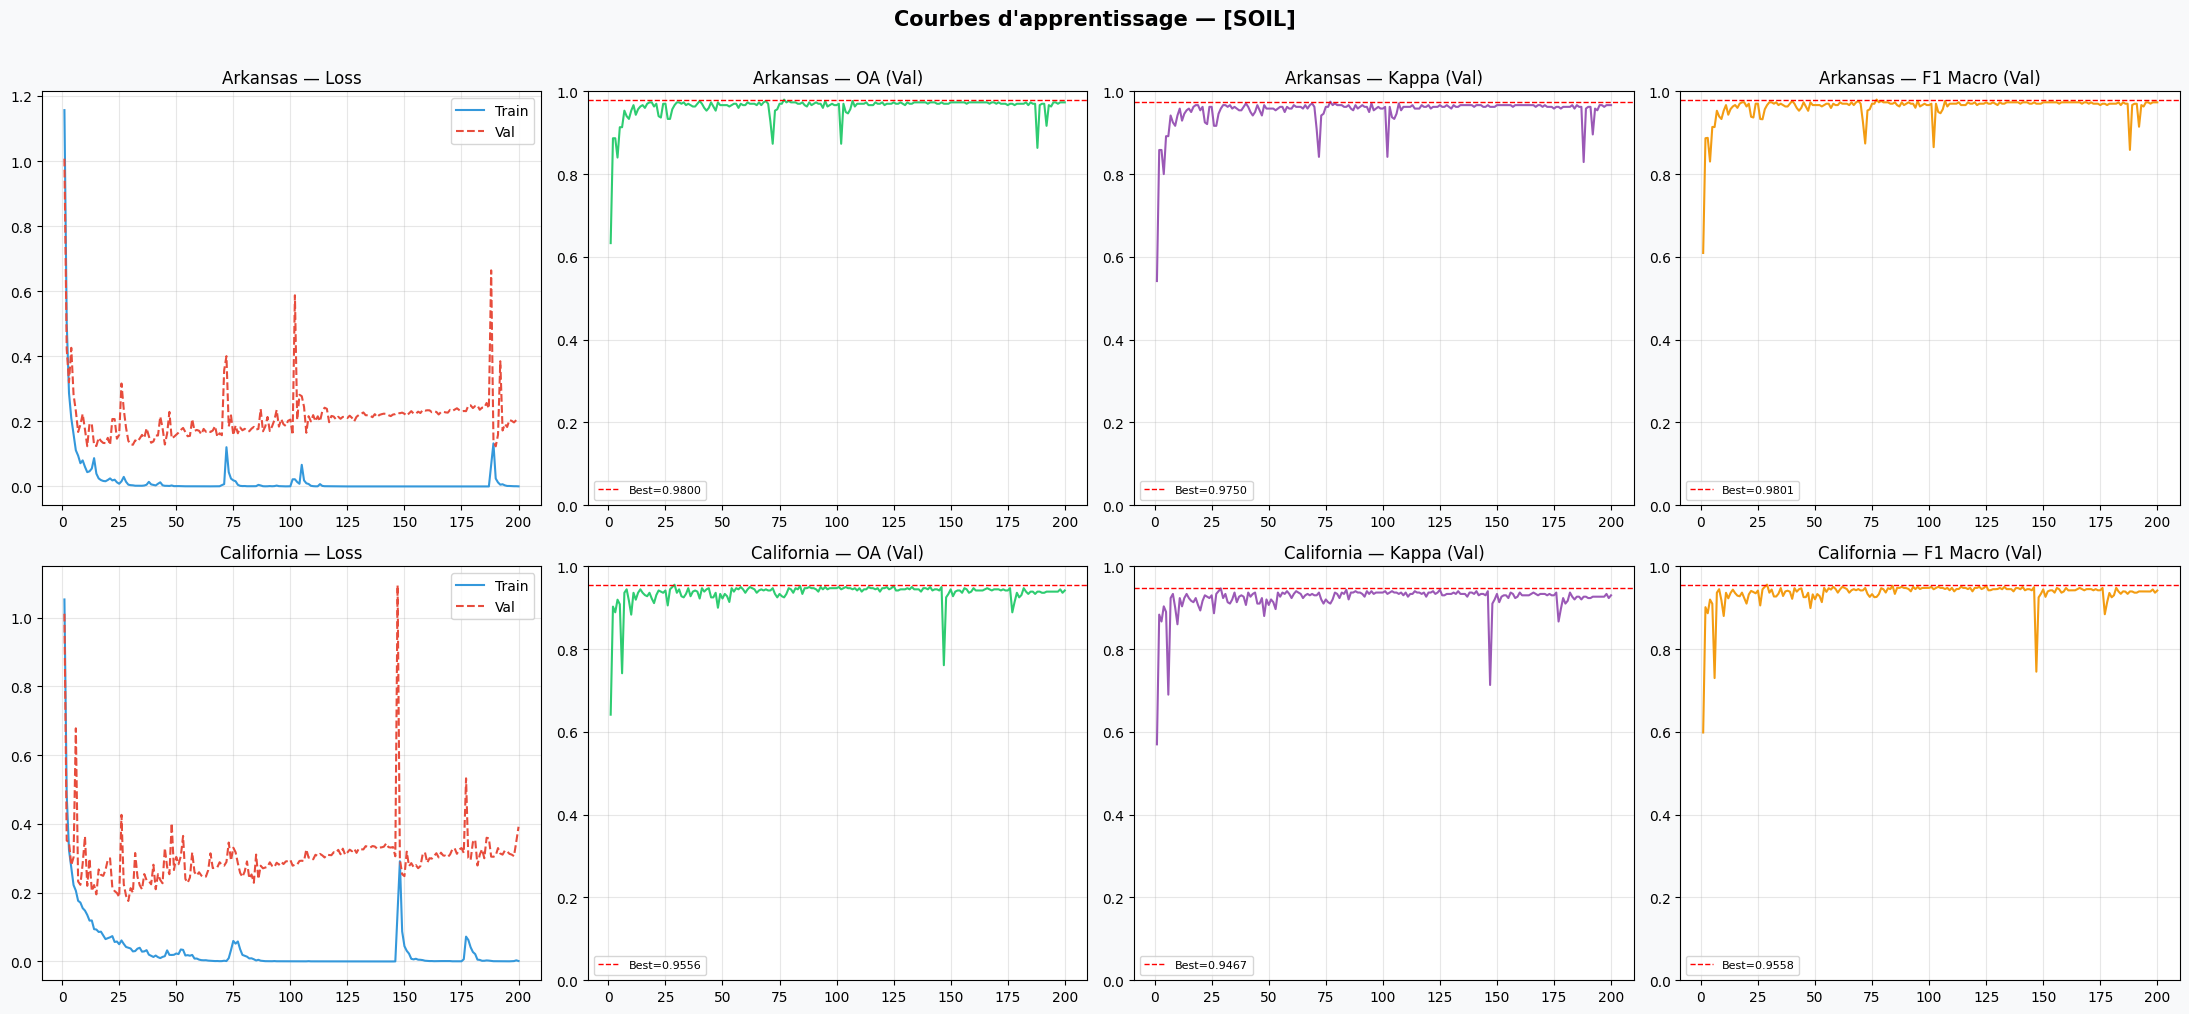

  Sauvegardé : curves_comparison_soil.png

── Courbes [CLIM] ──


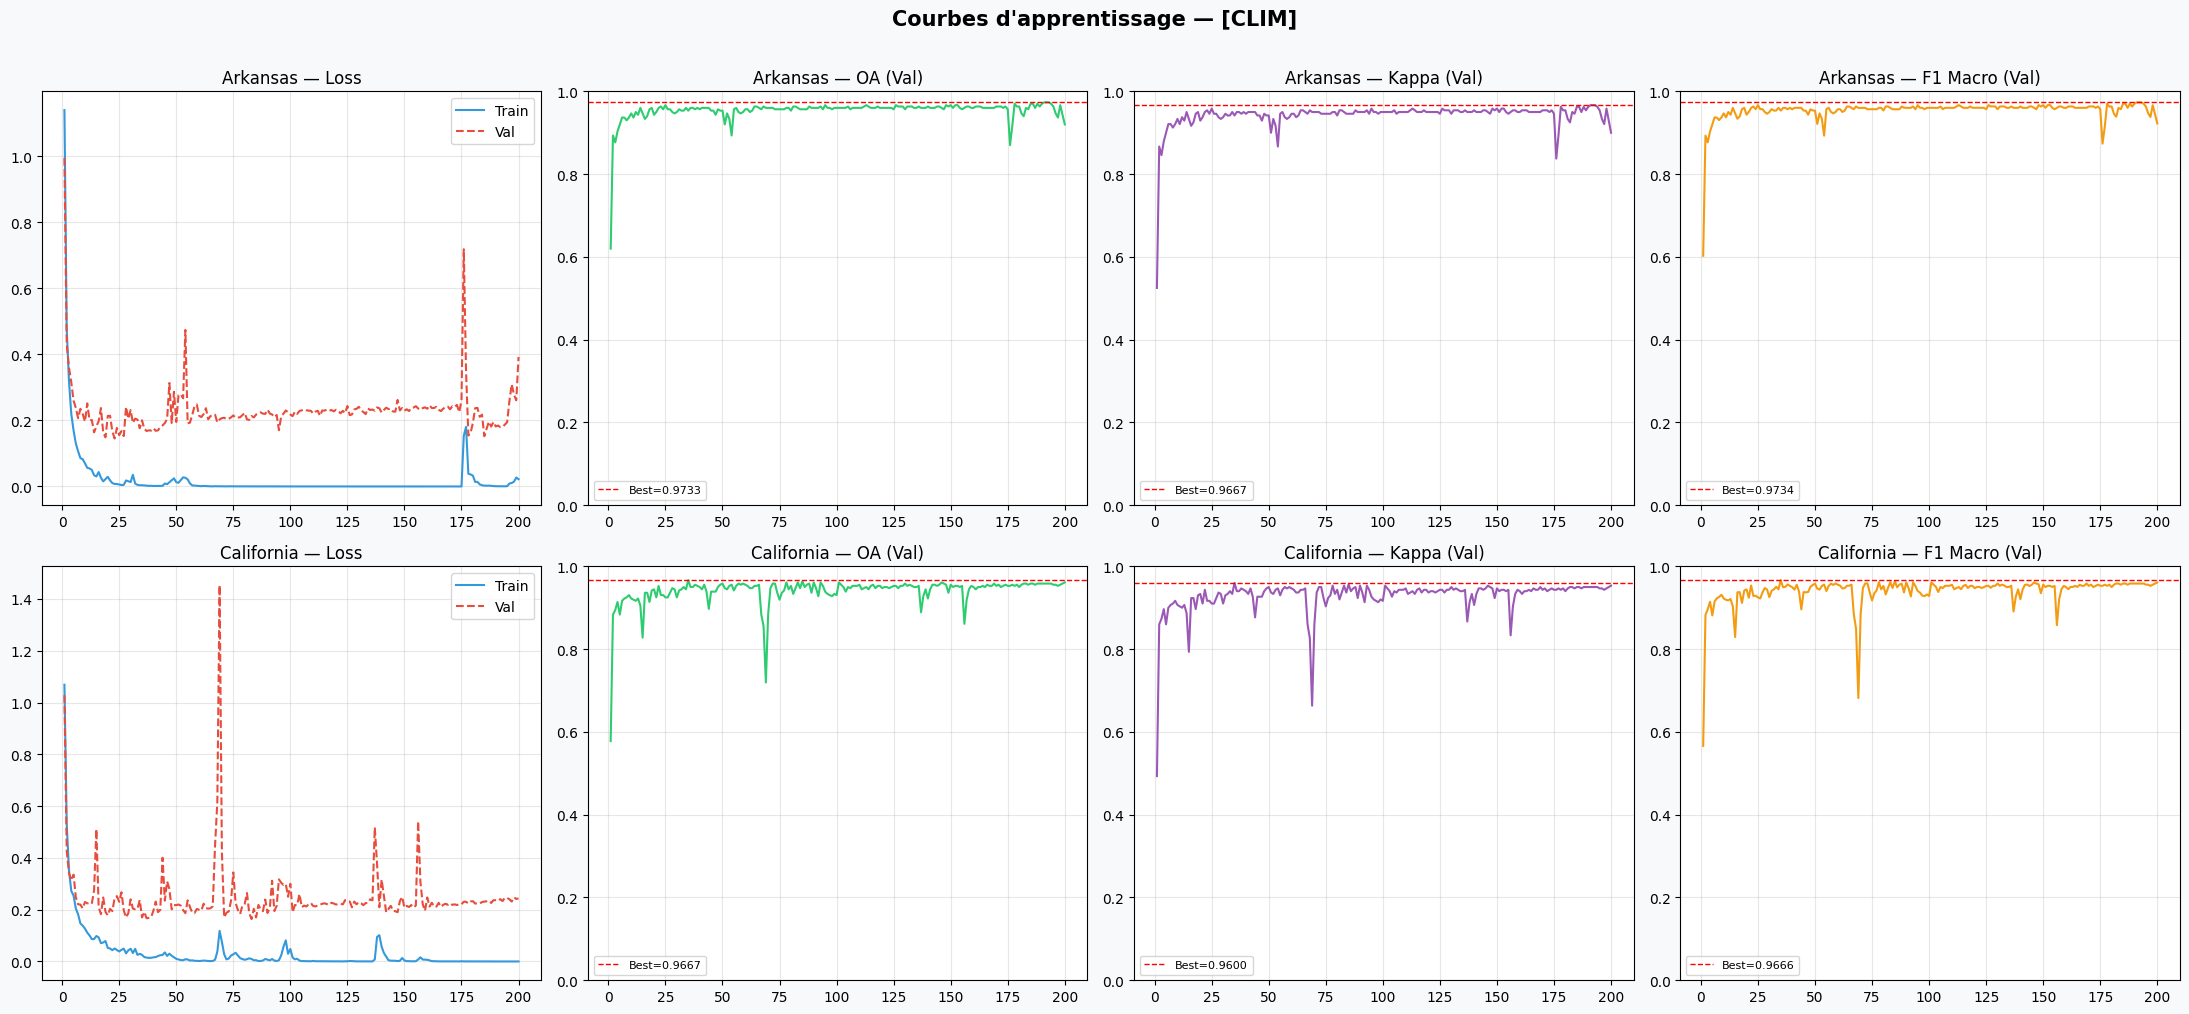

  Sauvegardé : curves_comparison_clim.png

── Courbes [TOPO] ──


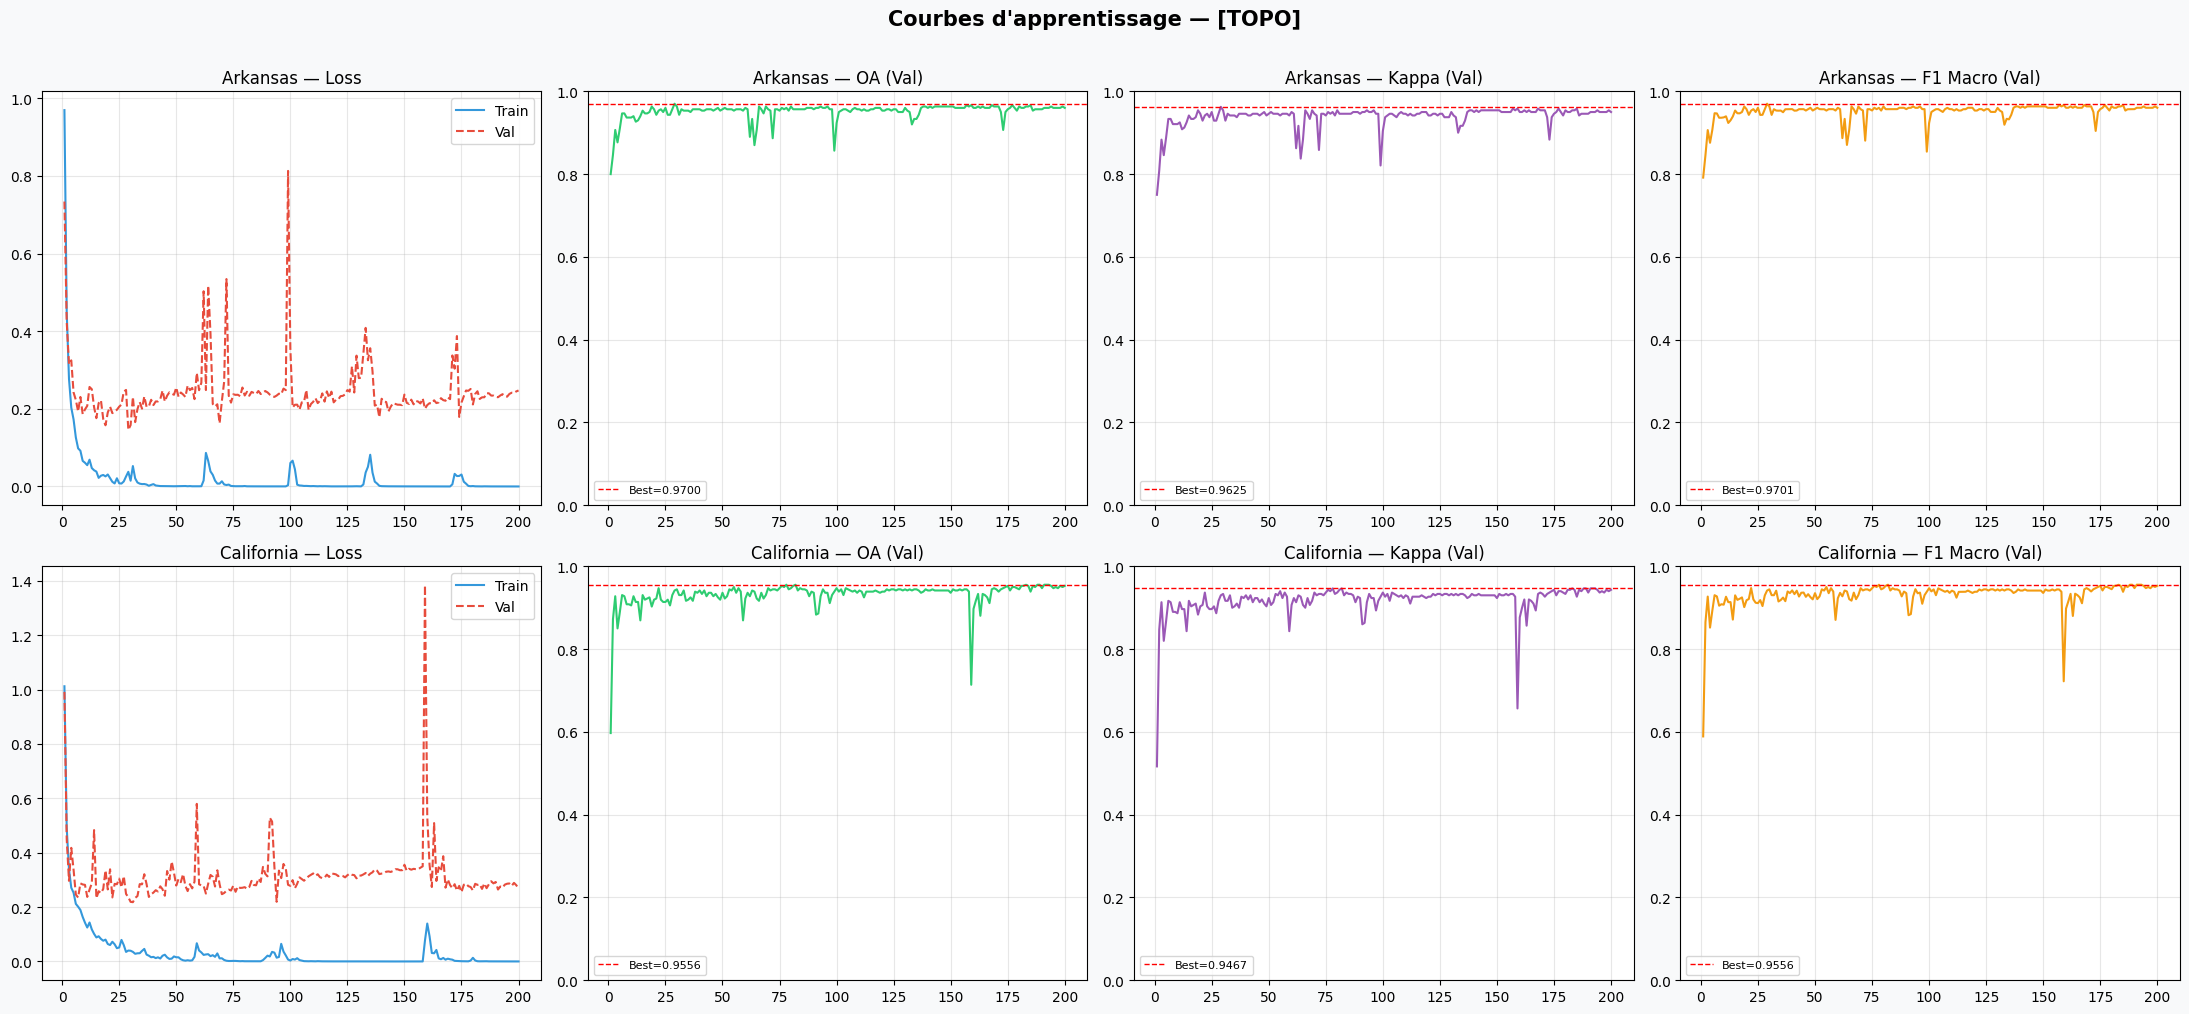

  Sauvegardé : curves_comparison_topo.png

── Courbes [CLIM_SOIL] ──


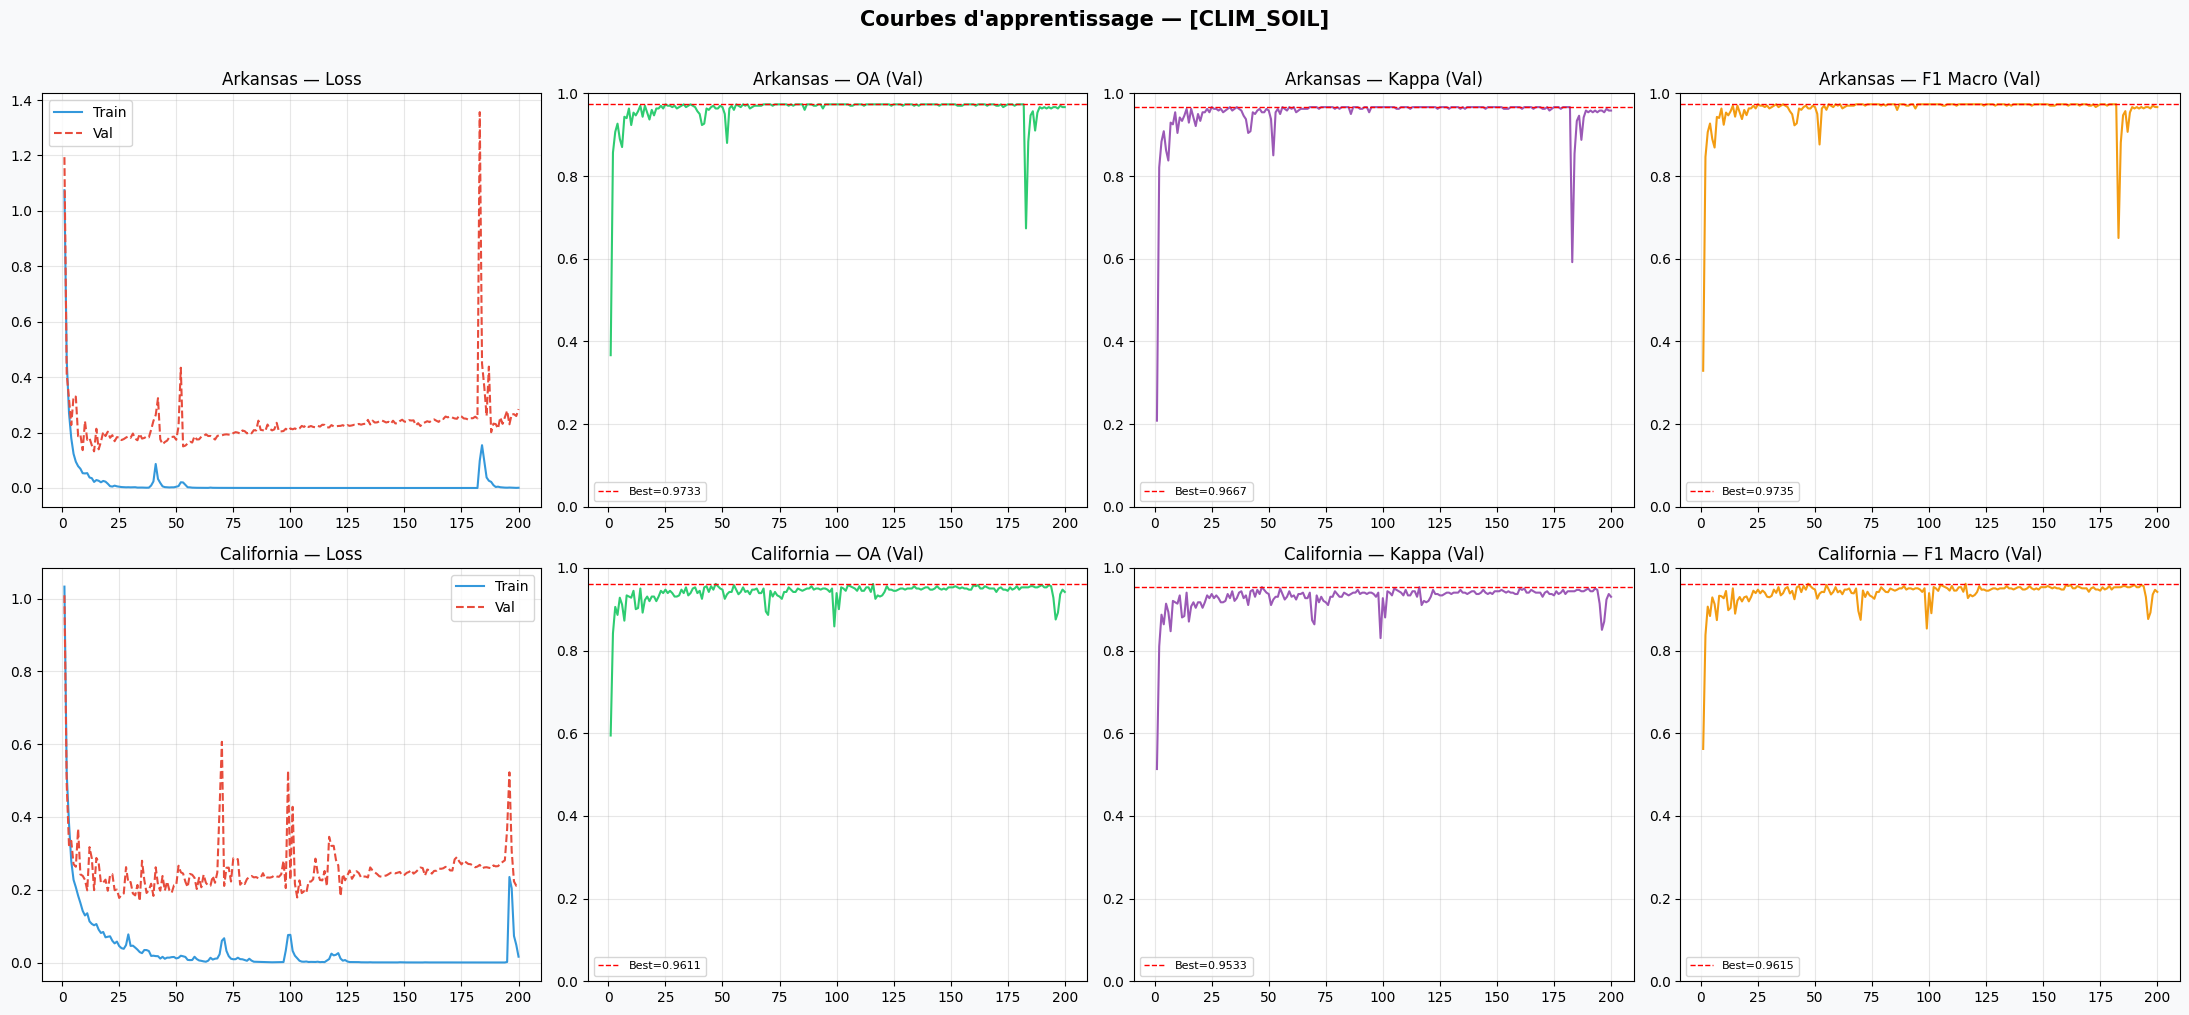

  Sauvegardé : curves_comparison_clim_soil.png

── Courbes [CLIM_TOPO] ──


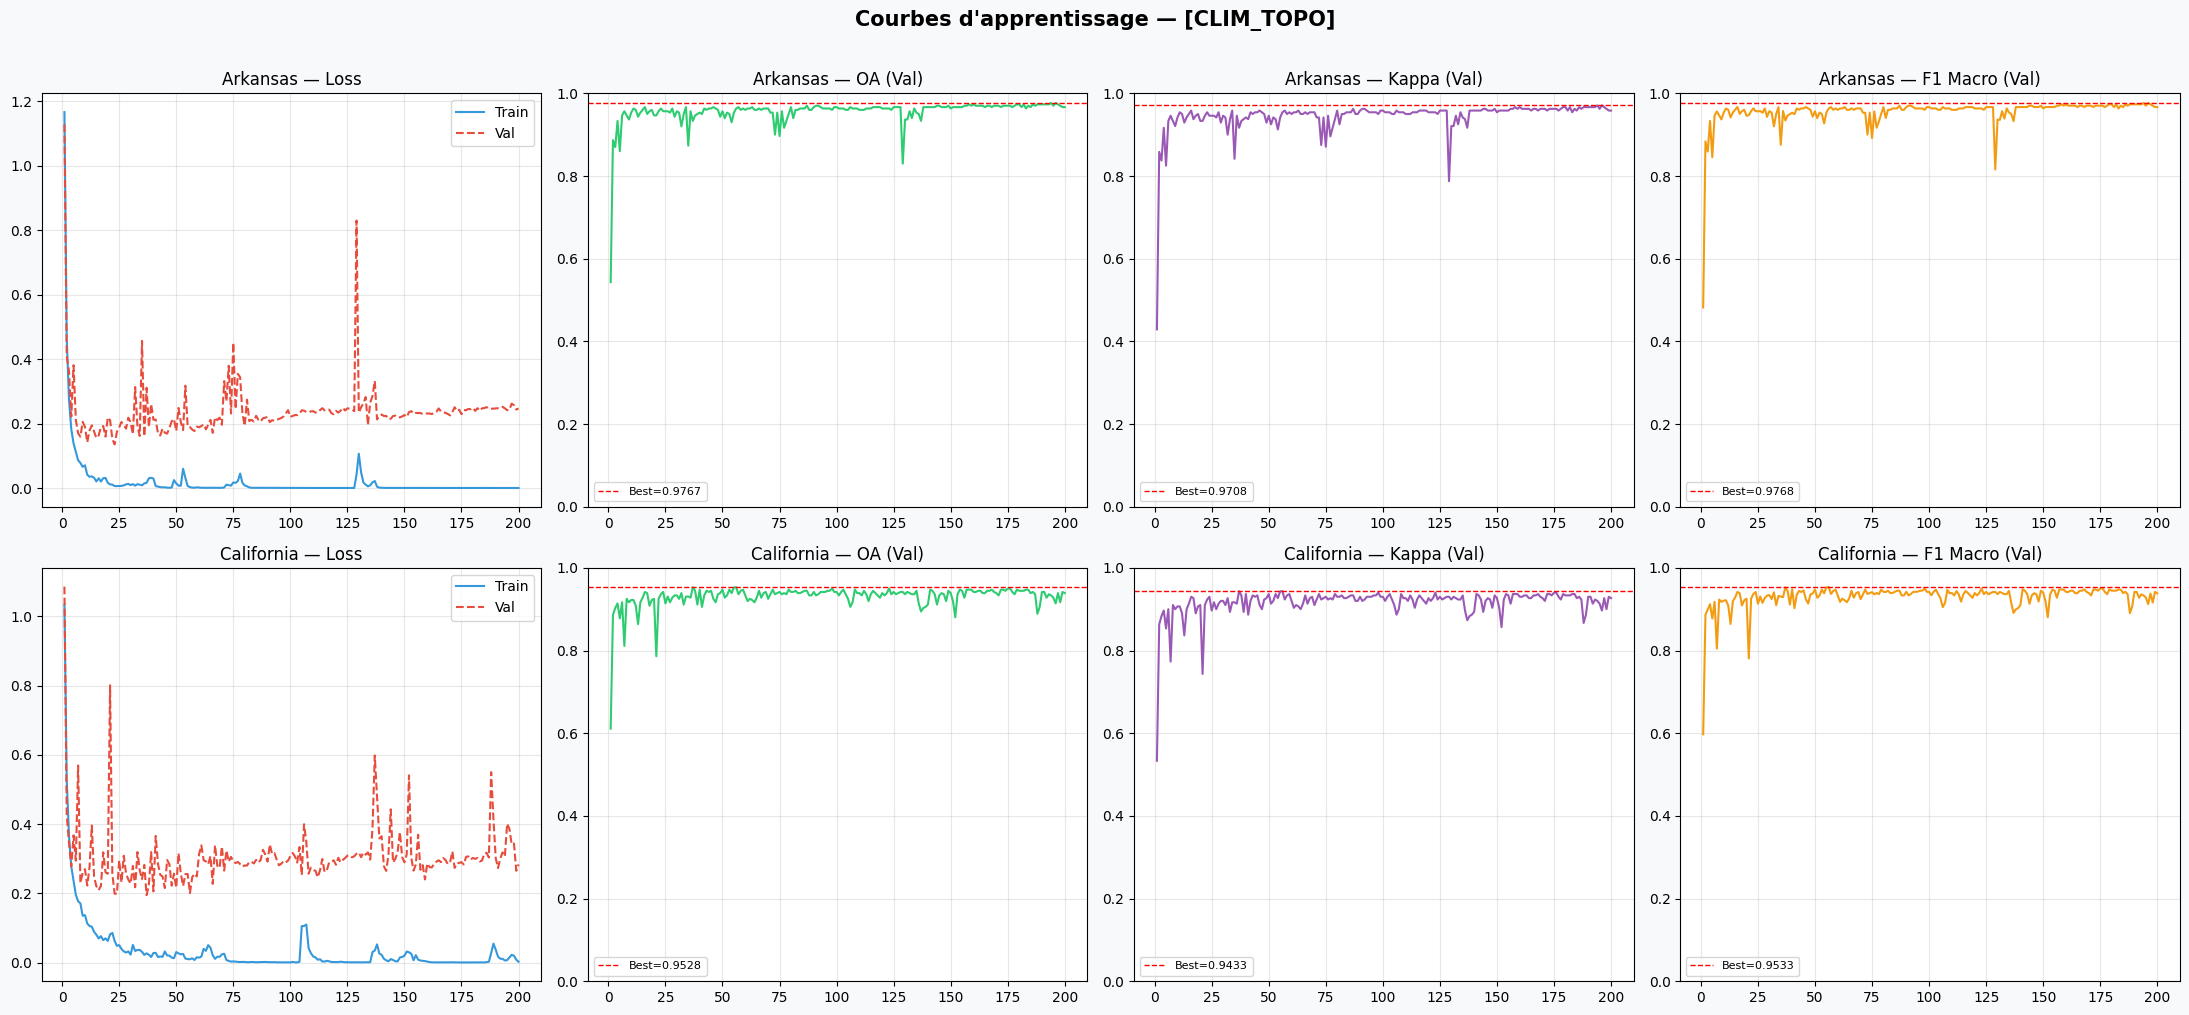

  Sauvegardé : curves_comparison_clim_topo.png

── Courbes [SOIL_TOPO] ──


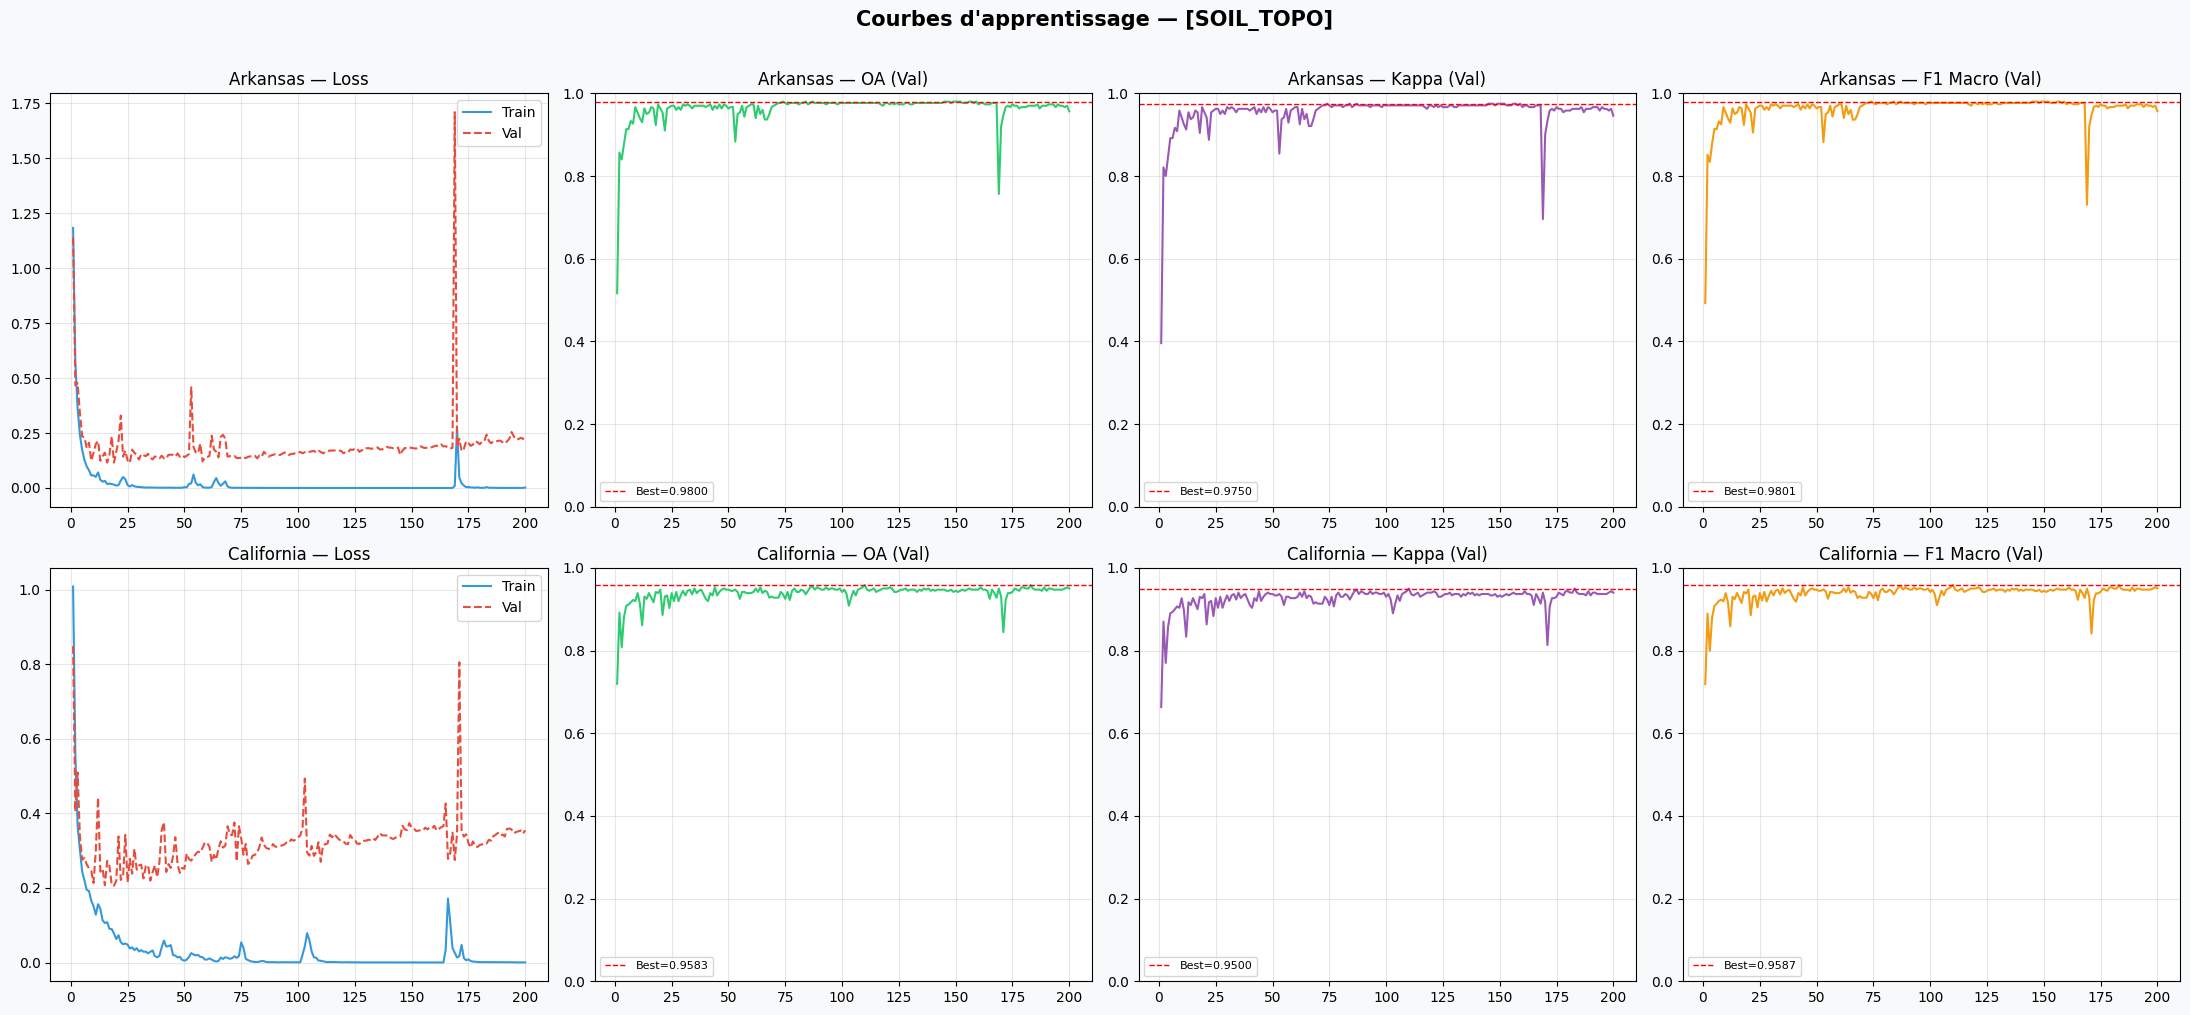

  Sauvegardé : curves_comparison_soil_topo.png

── Courbes [ALL] ──


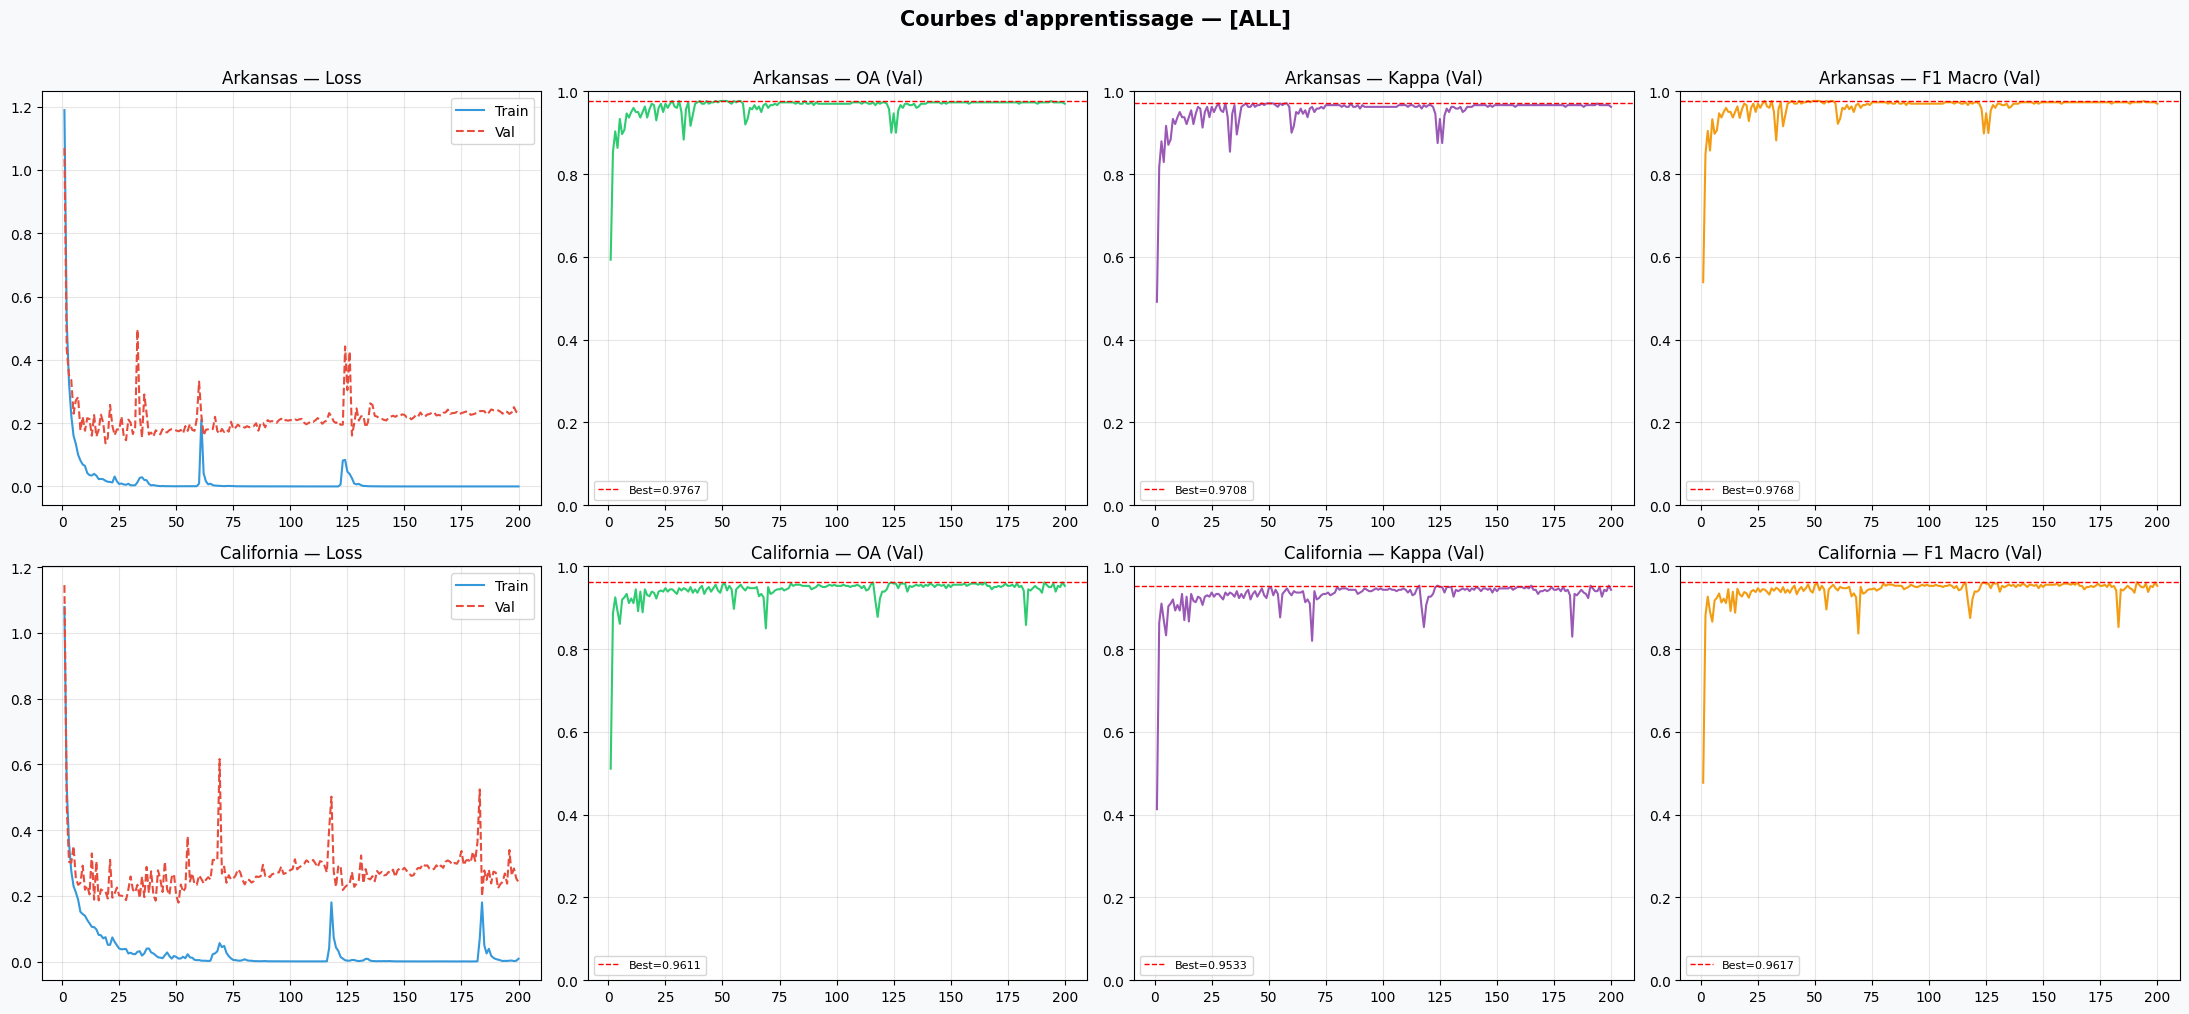

  Sauvegardé : curves_comparison_all.png


In [18]:
for cov_group in COV_GROUPS:
    print(f'\n── Courbes [{cov_group.upper()}] ──')
    plot_curves_comparison(all_histories, cov_group)

## Visualisations — Matrices de confusion côte à côte


── Matrice de confusion [SOIL] ──


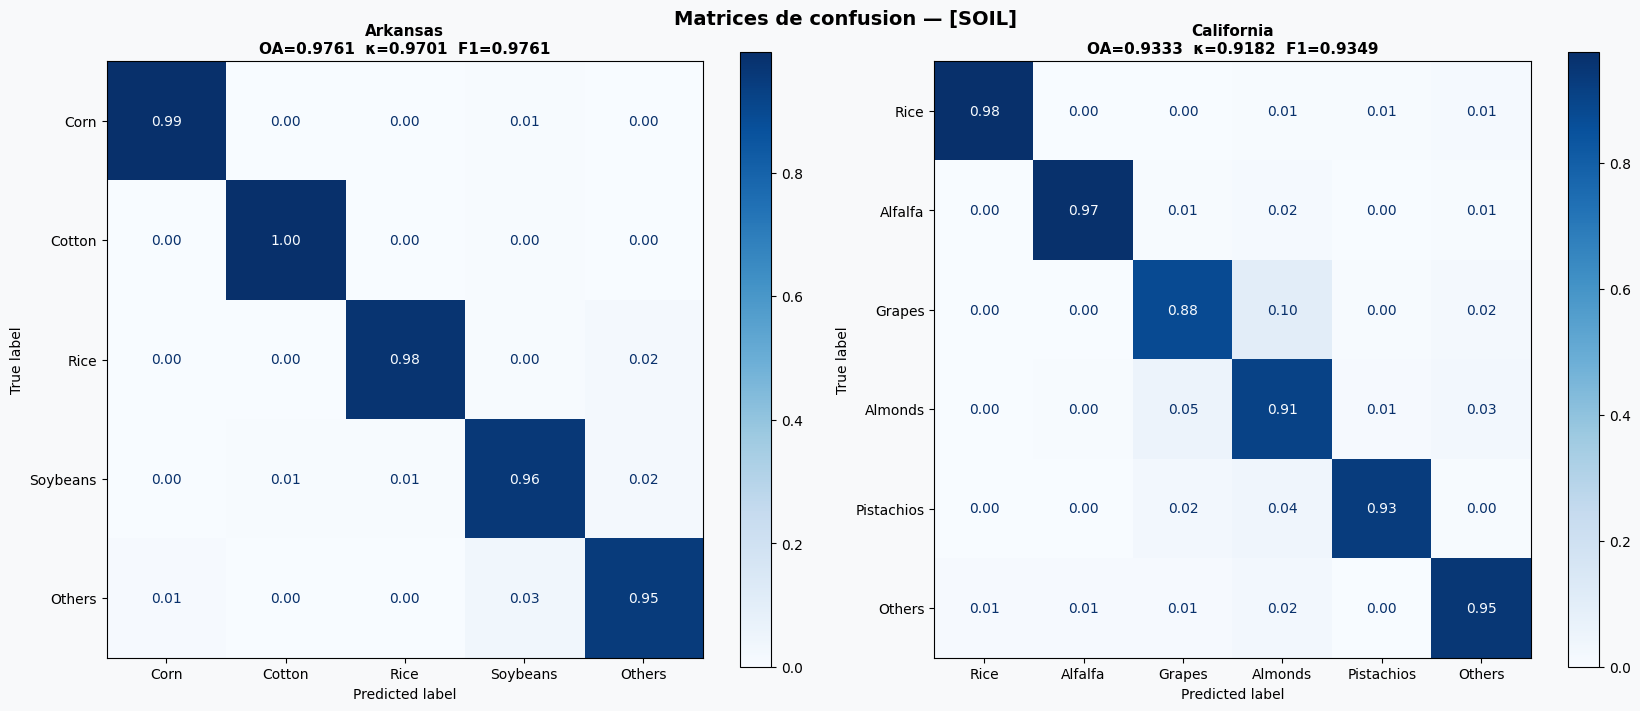

  Sauvegardé : confusion_comparison_soil.png

── Matrice de confusion [CLIM] ──


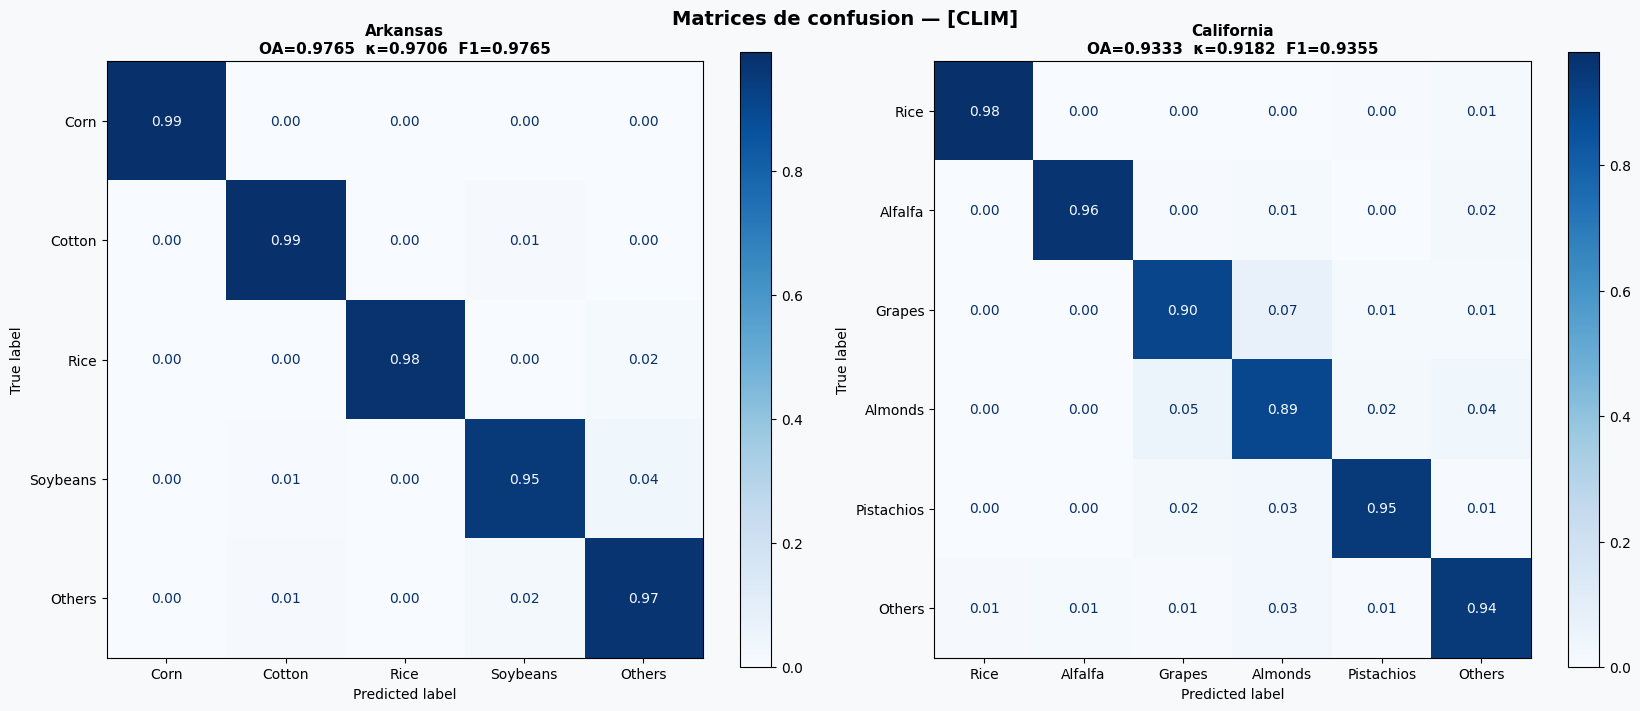

  Sauvegardé : confusion_comparison_clim.png

── Matrice de confusion [TOPO] ──


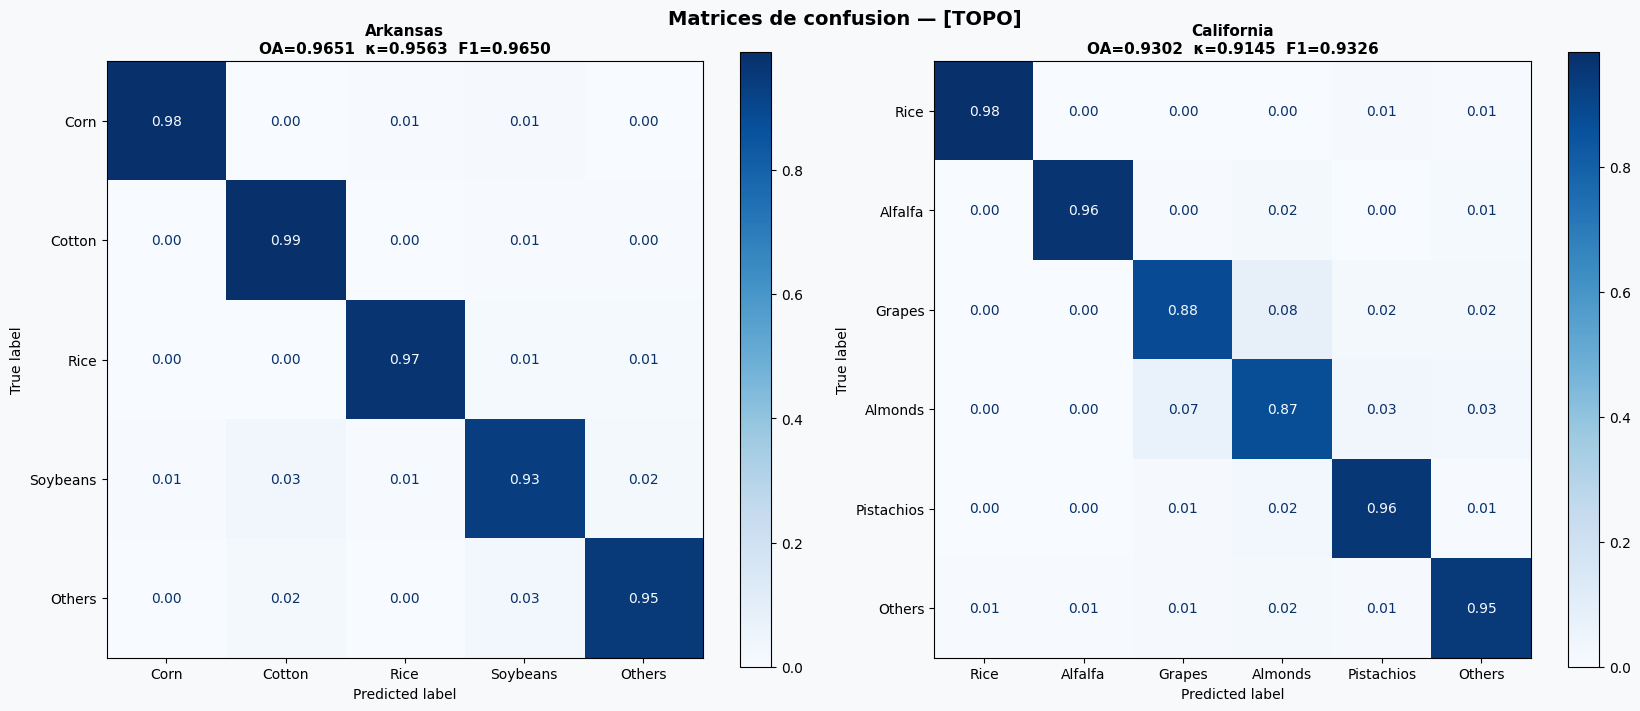

  Sauvegardé : confusion_comparison_topo.png

── Matrice de confusion [CLIM_SOIL] ──


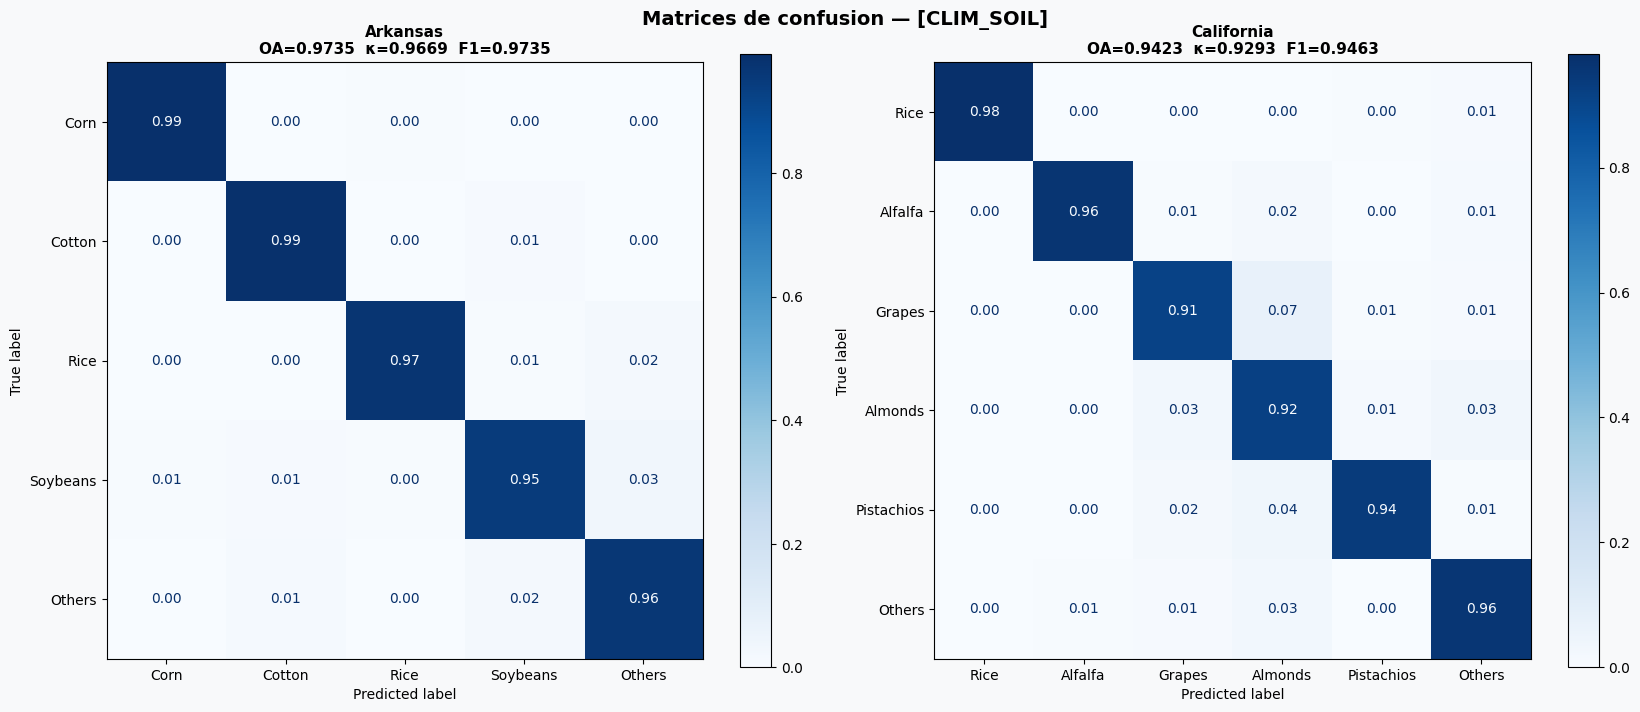

  Sauvegardé : confusion_comparison_clim_soil.png

── Matrice de confusion [CLIM_TOPO] ──


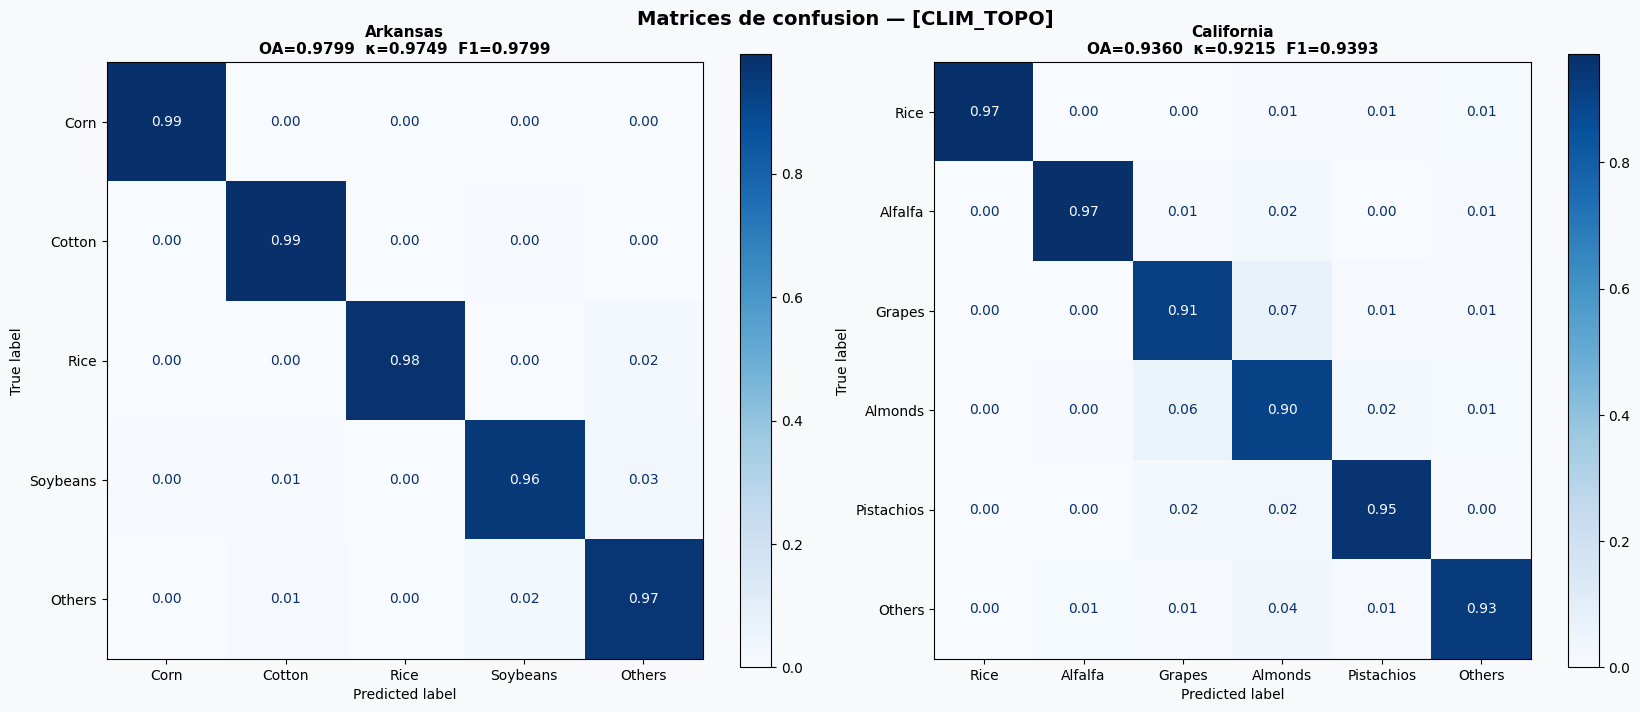

  Sauvegardé : confusion_comparison_clim_topo.png

── Matrice de confusion [SOIL_TOPO] ──


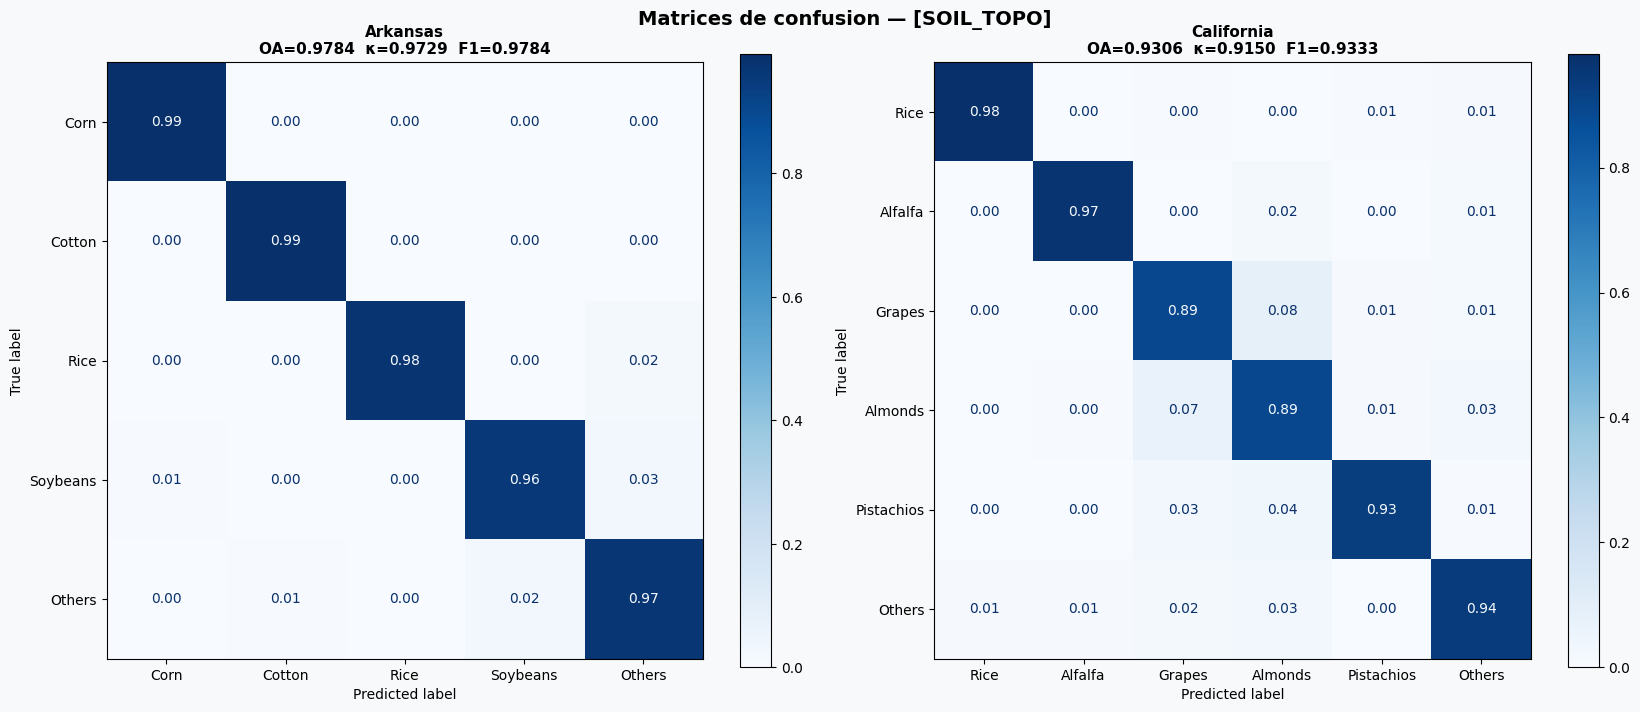

  Sauvegardé : confusion_comparison_soil_topo.png

── Matrice de confusion [ALL] ──


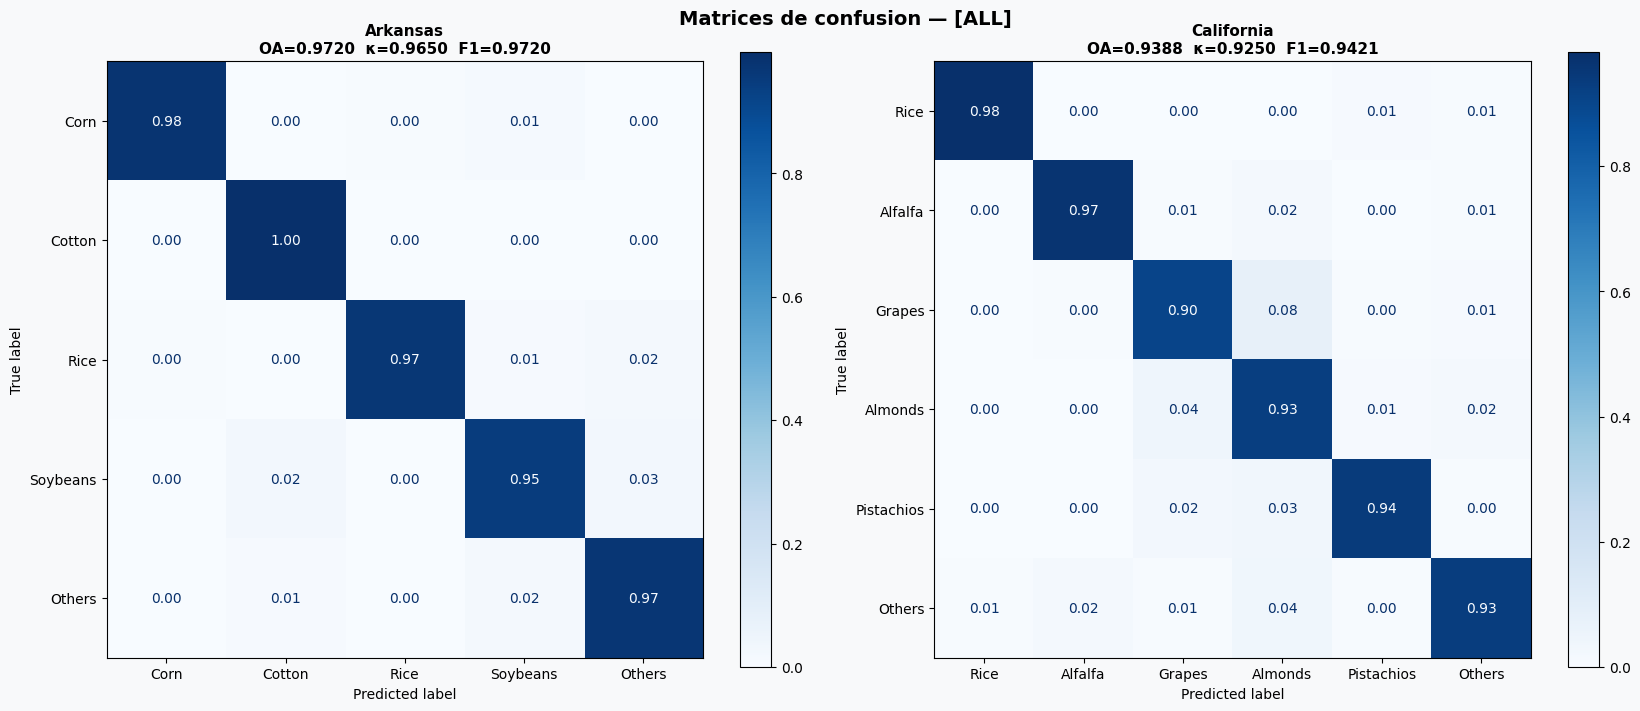

  Sauvegardé : confusion_comparison_all.png


In [19]:
for cov_group in COV_GROUPS:
    print(f'\n── Matrice de confusion [{cov_group.upper()}] ──')
    plot_confusion_comparison(all_models, all_results, cov_group, device)

## Visualisation — Comparaison en barres (toutes métriques)

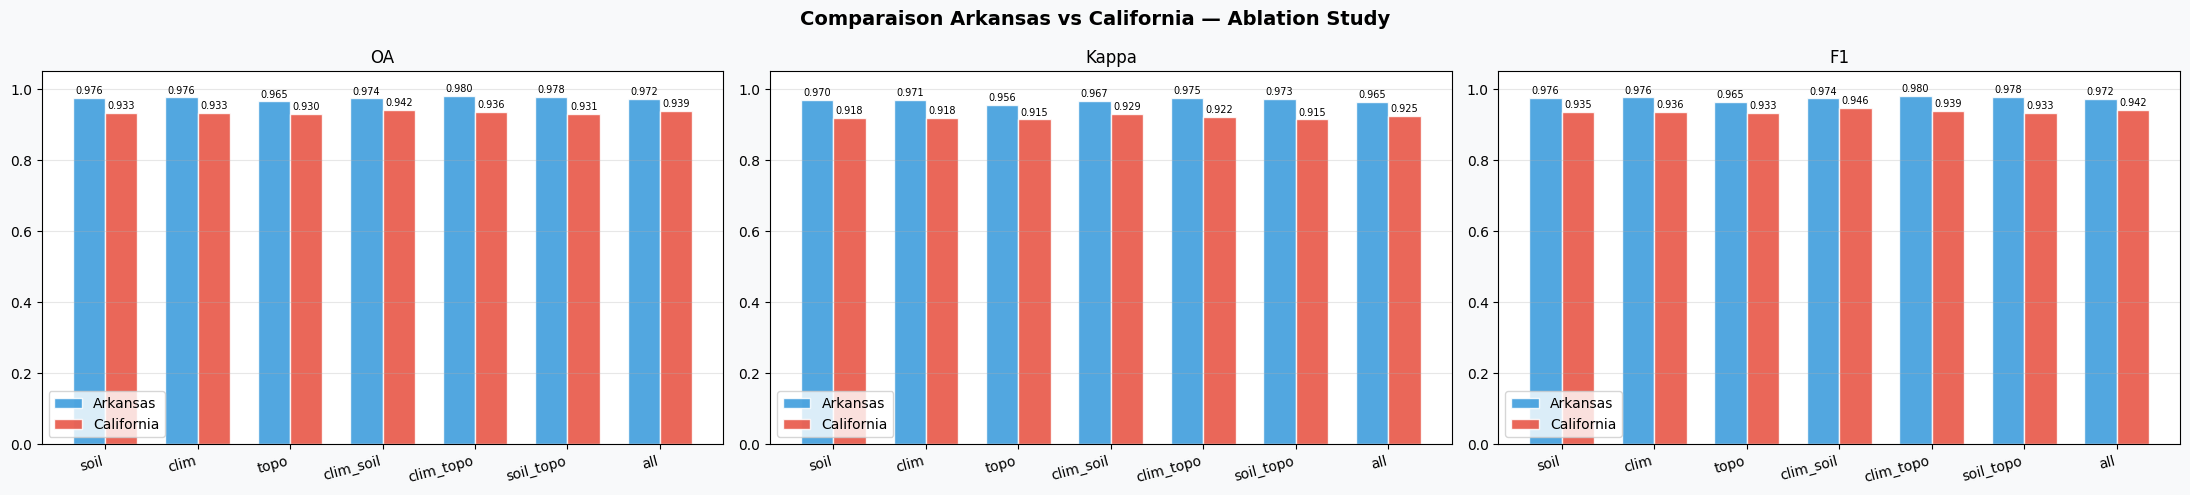


════════════════════════════════════════════════════════════════════════
  ABLATION STUDY — Arkansas vs California
════════════════════════════════════════════════════════════════════════
  Région         Groupe              OA     Kappa        F1
  ────────────────────────────────────────────────────────────
  Arkansas       soil            0.9761    0.9701    0.9761
  Arkansas       clim            0.9765    0.9706    0.9765
  Arkansas       topo            0.9651    0.9563    0.9650
  Arkansas       clim_soil       0.9735    0.9669    0.9735
  Arkansas       clim_topo       0.9799    0.9749    0.9799
  Arkansas       soil_topo       0.9784    0.9729    0.9784
  Arkansas       all             0.9720    0.9650    0.9720
  ────────────────────────────────────────────────────────────
  California     soil            0.9333    0.9182    0.9349
  California     clim            0.9333    0.9182    0.9355
  California     topo            0.9302    0.9145    0.9326
  California     clim_soi

In [20]:
plot_bar_comparison(all_results)
print_ablation_table(all_results)

## Export des résultats (CSV + Drive)

In [21]:
import csv, io

# ── Tableau CSV en mémoire ────────────────────────────────────────────────────
rows = [['Region', 'CovGroup', 'OA', 'Kappa', 'F1']]
for region in ['Arkansas', 'California']:
    for grp in ['soil', 'clim', 'topo', 'clim_soil', 'clim_topo', 'soil_topo', 'all']:
        r = all_results.get(region, {}).get(grp)
        if r:
            rows.append([region, grp, f'{r["OA"]:.6f}', f'{r["Kappa"]:.6f}', f'{r["F1"]:.6f}'])

csv_path = 'ablation_results.csv'
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(rows)
print(f'CSV sauvegardé : {csv_path}')

# ── Copie optionnelle sur Drive ───────────────────────────────────────────────
import shutil
drive_out = '/content/drive/MyDrive/data_part2/results/'
os.makedirs(drive_out, exist_ok=True)

# Copier CSV
shutil.copy(csv_path, drive_out + csv_path)

# Copier figures
for fname in os.listdir('.'):
    if fname.endswith('.png'):
        shutil.copy(fname, drive_out + fname)

# Copier modèles .pth
for region in all_models:
    for grp, pth in all_models[region].items():
        if os.path.exists(pth):
            shutil.copy(pth, drive_out + pth)

print(f'\nTous les fichiers exportés vers : {drive_out}')
print('Contenu :')
for f in sorted(os.listdir(drive_out)):
    print(f'  {f}')

CSV sauvegardé : ablation_results.csv

Tous les fichiers exportés vers : /content/drive/MyDrive/data_part2/results/
Contenu :
  ablation_comparison.png
  ablation_results.csv
  best_Arkansas_all.pth
  best_Arkansas_clim.pth
  best_Arkansas_clim_soil.pth
  best_Arkansas_clim_topo.pth
  best_Arkansas_soil.pth
  best_Arkansas_soil_topo.pth
  best_Arkansas_topo.pth
  best_California_all.pth
  best_California_clim.pth
  best_California_clim_soil.pth
  best_California_clim_topo.pth
  best_California_soil.pth
  best_California_soil_topo.pth
  best_California_topo.pth
  confusion_comparison_all.png
  confusion_comparison_clim.png
  confusion_comparison_clim_soil.png
  confusion_comparison_clim_topo.png
  confusion_comparison_soil.png
  confusion_comparison_soil_topo.png
  confusion_comparison_topo.png
  curves_comparison_all.png
  curves_comparison_clim.png
  curves_comparison_clim_soil.png
  curves_comparison_clim_topo.png
  curves_comparison_soil.png
  curves_comparison_soil_topo.png
  curve